## Settings and Utilities

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    'font.size': 16,         # base font size
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x, y axis labels
    'xtick.labelsize': 14,   # x-axis ticks
    'ytick.labelsize': 14,   # y-axis ticks
    'legend.fontsize': 14,   # legend
    'figure.titlesize': 18
})

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ============================================================
# Dataset root folder.
# Change this single line if the Drive folder is renamed or moved;
# every dataset path in this notebook is derived from it.
# ============================================================
DATA_ROOT = Path('/content/drive/MyDrive/PHM Practice/Datasets')
PROJECT_ROOT = DATA_ROOT.parent   # for outputs saved outside Datasets/


# ------------------------------------------------------------------
# Shared helper functions used in more than one section below.
# ------------------------------------------------------------------

def first_crossing(tgrid, curve, threshold, current_time):
    # Interpolated time at which `curve` first reaches `threshold`
    # at or after `current_time`; returns np.nan if it never does.
    idx = np.where((tgrid >= current_time) & (curve >= threshold))[0]
    if len(idx) == 0:
        return np.nan
    j = idx[0]
    if j == 0:
        return max(tgrid[j] - current_time, 0.0)
    return np.interp(threshold, [curve[j - 1], curve[j]],
                      [tgrid[j - 1], tgrid[j]]) - current_time


def target_pdf_unnorm(x):
    # Unnormalized bimodal target density for the importance-sampling demo.
    return 0.3 * np.exp(-0.2 * x**2) + 0.7 * np.exp(-0.2 * (x - 10)**2)


def proposal_pdf(x):
    # Gaussian proposal density N(mu_q, sigma_q^2); mu_q/sigma_q are set
    # in each demo cell before this is called.
    return norm.pdf(x, loc=mu_q, scale=sigma_q)


## Life definition

### Histogram

Mean: 42.833333333333336
std: 20.27984768735264
10th percentile: 15.8


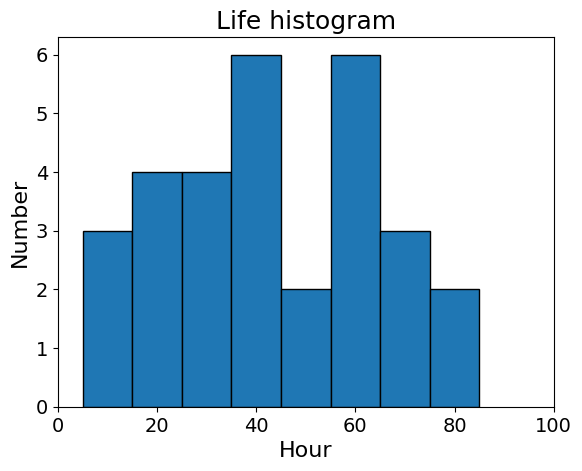

et = 48.44202091143349, m = 2.272113899225488


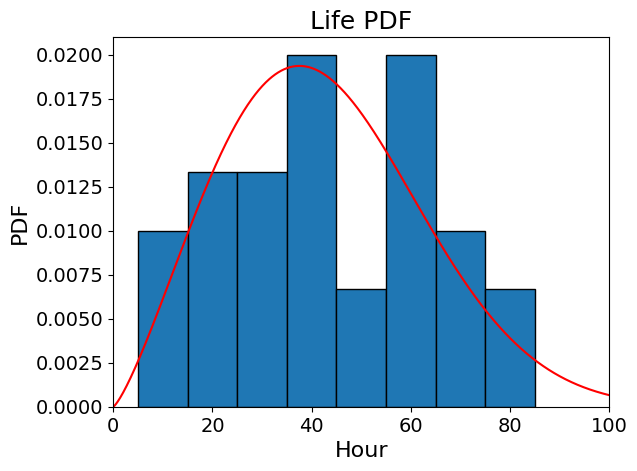

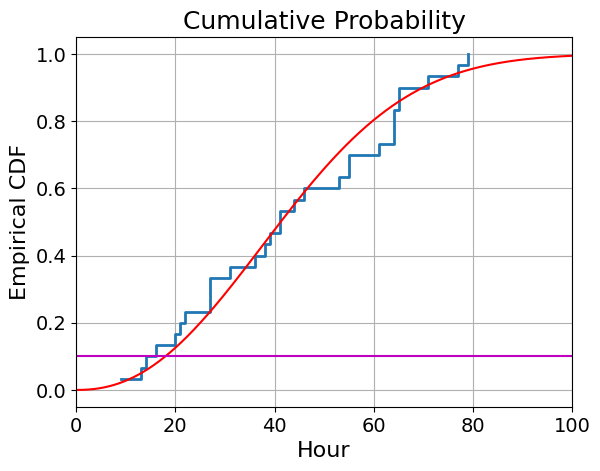

B10 life: 17.992206869098972


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = np.array([9, 13, 14, 16, 20, 21, 22, 27, 27, 27, 31, 36, 38, 39, 41, 41, 44, 46, 53,
              55, 55, 61, 64, 64, 64, 65, 65, 71, 77, 79])
n = len(T)

print('Mean:', np.mean(T))
print('std:', np.std(T))
print('10th percentile:', np.percentile(T, 10))

plt.figure()
plt.hist(T, bins=range(5, 86, 10), edgecolor='black')
plt.title('Life histogram')
plt.xlabel('Hour')
plt.ylabel('Number')
plt.xlim(0, 100)
plt.show()

from scipy import stats

plt.figure()
counts, bins, _ = plt.hist(T, bins=range(5, 86, 10), density=True, edgecolor='black')
plt.title('Life PDF')
plt.xlabel('Hour')
plt.ylabel('PDF')
plt.xlim(0, 100)

shape, loc, scale = stats.weibull_min.fit(T, floc=0)
et, m = scale, shape
print(f'et = {et}, m = {m}')

t = np.linspace(0, 100, 1000)
pdf = stats.weibull_min.pdf(t, m, loc=0, scale=et)
plt.plot(t, pdf, 'r-')
plt.show()

plt.figure()
plt.step(T, np.arange(1, n+1) / n, where='post', linewidth=2)
plt.title('Cumulative Probability')
plt.xlabel('Hour')
plt.ylabel('Empirical CDF')
plt.grid(True)
plt.xlim(0, 100)

cdf = stats.weibull_min.cdf(t, m, loc=0, scale=et)
plt.plot(t, cdf, 'r-')

plt.plot([0, 100], [0.1, 0.1], 'm-')
plt.show()

b10 = stats.weibull_min.ppf(0.1, m, loc=0, scale=et)
print(f'B10 life: {b10}')

### Draw samples from Weibull parameters

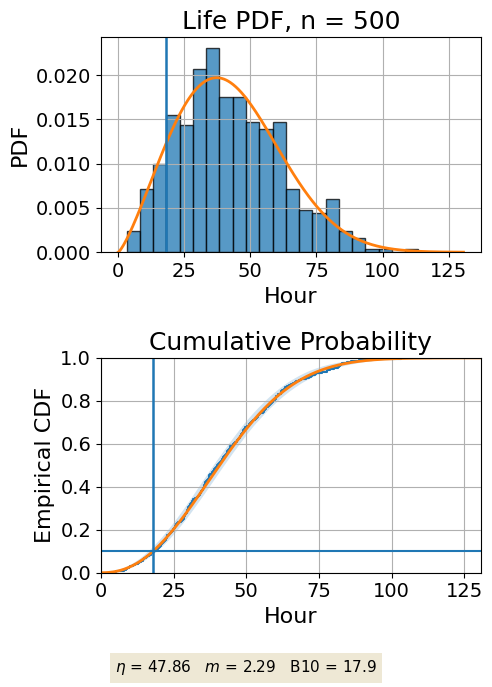

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# User input
eta_true, m_true = et, m
n, seed, n_boot = 500, 1, 1000

# Generate data and fit Weibull distribution
rng = np.random.default_rng(seed)
x = weibull_min.rvs(m_true, scale=eta_true, size=n, random_state=rng)
m_hat, _, eta_hat = weibull_min.fit(x, floc=0)
b10 = weibull_min.ppf(0.1, m_hat, scale=eta_hat)

# Fitted PDF and CDF
t = np.linspace(0, max(1.15 * x.max(), 100), 500)
pdf = weibull_min.pdf(t, m_hat, scale=eta_hat)
cdf = weibull_min.cdf(t, m_hat, scale=eta_hat)

# Bootstrap 95% confidence interval
params = [weibull_min.fit(rng.choice(x, n), floc=0) for _ in range(n_boot)]
cdf_boot = [weibull_min.cdf(t, p[0], scale=p[2]) for p in params]
cdf_low, cdf_high = np.percentile(cdf_boot, [2.5, 97.5], axis=0)

# Plot
fig, ax = plt.subplots(2, 1, figsize=(5.2, 7))

ax[0].hist(x, bins=max(8, int(np.sqrt(n))), density=True,
           edgecolor="black", alpha=0.75)
ax[0].plot(t, pdf, linewidth=2)
ax[0].axvline(b10, linewidth=1.8)
ax[0].set(title=f"Life PDF, n = {n}", xlabel="Hour", ylabel="PDF")
ax[0].grid()

x_sort = np.sort(x)
ax[1].step(x_sort, np.arange(1, n + 1) / n, where="post", linewidth=1.5)
ax[1].plot(t, cdf, linewidth=2)
ax[1].fill_between(t, cdf_low, cdf_high, alpha=0.2)
ax[1].axhline(0.1, linewidth=1.5)
ax[1].axvline(b10, linewidth=1.8)
ax[1].set(title="Cumulative Probability", xlabel="Hour",
          ylabel="Empirical CDF", xlim=(0, t[-1]), ylim=(0, 1))
ax[1].grid()

fig.text(
    0.5, 0.02,
    rf"$\eta$ = {eta_hat:.2f}   $m$ = {m_hat:.2f}   B10 = {b10:.1f}",
    ha="center", fontsize=11,
    bbox=dict(facecolor="#eee8d5", edgecolor="none", pad=4)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Prognosis by linear regression

### Linear regression

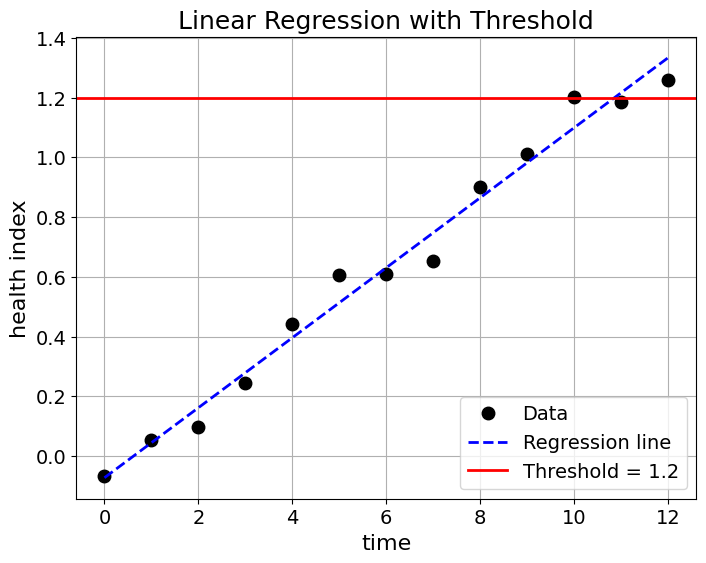

Regression equation:
y = -0.0725 + 0.1171 t

Regression coefficients:
b0 = -0.07245494505494521
b1 = 0.11714505494505496

Residual standard deviation:
s = 0.0640446914076608

Parameter covariance matrix P:
[[ 1.12684684e-03 -1.35221621e-04]
 [-1.35221621e-04  2.25369368e-05]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

# ------------------------------------------------------------
# Data: 13 measurements
# ------------------------------------------------------------
y = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586
])

n = len(y)

# Time/index variable
t = np.arange(n)   # 0, 1, 2, ..., 12

# ------------------------------------------------------------
# Linear regression model: y = b0 + b1*t
# ------------------------------------------------------------
F = np.column_stack((np.ones(n), t))

# Least-squares estimate
b = np.linalg.solve(F.T @ F, F.T @ y)

# Regression estimate
yr = F @ b

# ------------------------------------------------------------
# Residual standard deviation
# ------------------------------------------------------------
residual = y - yr
s = np.sqrt((residual.T @ residual) / (n - 2))

# ------------------------------------------------------------
# Parameter covariance matrix
# ------------------------------------------------------------
P = np.linalg.inv(F.T @ F) * s**2

# ------------------------------------------------------------
# Confidence interval for regression mean
# ------------------------------------------------------------
varyr = np.diag(F @ P @ F.T)

t_low = t_dist.ppf(0.025, n - 2)
t_high = t_dist.ppf(0.975, n - 2)

yc_low = yr + t_low * np.sqrt(varyr)
yc_high = yr + t_high * np.sqrt(varyr)

# ------------------------------------------------------------
# Prediction interval for new observations
# ------------------------------------------------------------
varyp = varyr + s**2

yp_low = yr + t_low * np.sqrt(varyp)
yp_high = yr + t_high * np.sqrt(varyp)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
threshold = 1.2

plt.figure(figsize=(8, 6))

plt.plot(t, y, 'ko', markersize=9, label='Data')
plt.plot(t, yr, 'b--', linewidth=2, label='Regression line')

plt.axhline(
    threshold,
    color='red',
    linestyle='-',
    linewidth=2,
    label='Threshold = 1.2'
)

plt.xlabel('time')
plt.ylabel('health index')
plt.title('Linear Regression with Threshold')
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------
print("Regression equation:")
print(f"y = {b[0]:.4f} + {b[1]:.4f} t")

print("\nRegression coefficients:")
print("b0 =", b[0])
print("b1 =", b[1])

print("\nResidual standard deviation:")
print("s =", s)

print("\nParameter covariance matrix P:")
print(P)

### Prognosis by linear reg

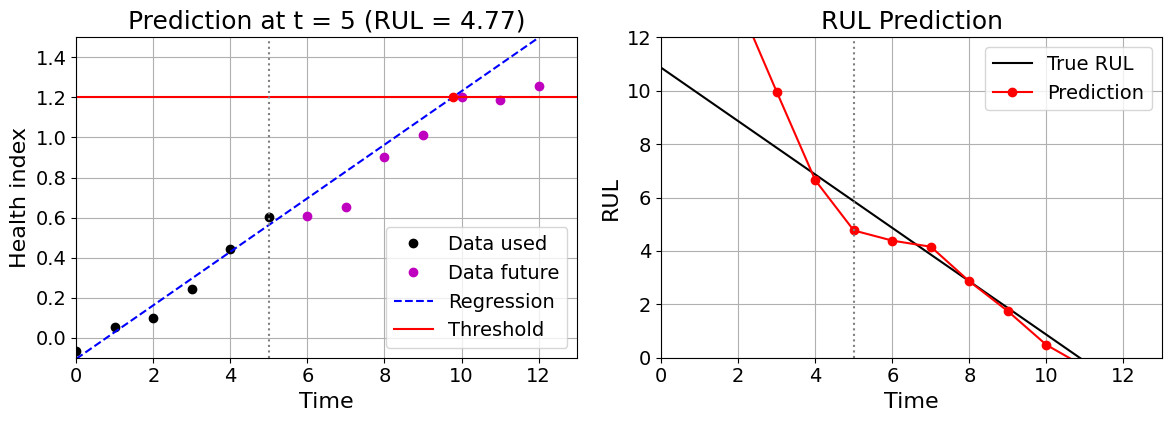

Predicted EOL at t=5: 9.767
Predicted RUL at t=5: 4.767
Full-data EOL: 10.862


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data and full-data EOL
y = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586
])
time = np.arange(len(y))
threshold = 1.2

# Least-squares linear fit using the first k points; returns (coeffs, EOL).
def fit_linear(k):
    F = np.column_stack((np.ones(k), time[:k]))
    b = np.linalg.lstsq(F, y[:k], rcond=None)[0]
    eol = (threshold - b[0]) / b[1] if b[1] > 0 else np.nan
    return b, eol

b_full, eolt = fit_linear(len(y))

# Sequential RUL prediction
k_values = np.arange(3, len(y))
rul = np.full(len(y), np.nan)
for k in k_values:
    b, eol = fit_linear(k)
    rul[k-1] = eol - time[k-1]

# Representative prediction at t = 5
current_time = 5
k_show = current_time + 1
b_show, eol_show = fit_linear(k_show)
tp = np.linspace(0, max(time[-1], eol_show) + 0.5, 400)
yp = b_show[0] + b_show[1] * tp

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(time[:k_show], y[:k_show], 'ko', label='Data used')
axes[0].plot(time[k_show:], y[k_show:], 'mo', label='Data future')
axes[0].plot(tp, yp, '--b', label='Regression')
axes[0].axhline(threshold, color='r', label='Threshold')
axes[0].plot(eol_show, threshold, 'ro')
axes[0].axvline(current_time, color='gray', linestyle=':')
axes[0].set_xlim(0, 13)
axes[0].set_ylim(-0.1, 1.5)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Health index')
axes[0].set_title(f'Prediction at t = {current_time} (RUL = {eol_show-current_time:.2f})')
axes[0].grid(True)
axes[0].legend()

valid = ~np.isnan(rul)
axes[1].plot(time, eolt - time, 'k', label='True RUL')
axes[1].plot(time[valid], rul[valid], 'ro-', label='Prediction')
axes[1].axvline(current_time, color='gray', linestyle=':')
axes[1].set_xlim(0, 13)
axes[1].set_ylim(0, 12)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RUL')
axes[1].set_title('RUL Prediction')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Predicted EOL at t={current_time}: {eol_show:.3f}')
print(f'Predicted RUL at t={current_time}: {eol_show-current_time:.3f}')
print(f'Full-data EOL: {eolt:.3f}')

### Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.subplots_adjust(
    left=0.07, right=0.98,
    bottom=0.14, top=0.90,
    wspace=0.16)

# Animation frame: linear-regression RUL prediction using the first k_values[frame] points.
def update(frame):
    k = k_values[frame]
    current_time = time[k-1]
    b, eol = fit_linear(k)
    tp = np.linspace(0, max(time[-1], eol) + 0.5, 400)
    yp = b[0] + b[1] * tp

    axes[0].clear()
    axes[0].plot(time[:k], y[:k], 'ko', label='Data used')
    axes[0].plot(time[k:], y[k:], 'mo', label='Data future')
    axes[0].plot(tp, yp, '--b', label='Regression')
    axes[0].axhline(threshold, color='r', label='Threshold')
    axes[0].plot(eol, threshold, 'ro')
    axes[0].axvline(current_time, color='gray', linestyle=':')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Health index')
    axes[0].set_title(f'Prediction at t = {current_time} (RUL = {eol-current_time:.2f})')
    axes[0].grid(True)
    axes[0].legend()

    shown = time <= current_time
    valid = shown & ~np.isnan(rul)
    axes[1].clear()
    axes[1].plot(time, eolt - time, 'k', label='True RUL')
    axes[1].plot(time[valid], rul[valid], 'ro-', label='Prediction')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('RUL')
    axes[1].set_title('RUL Prediction')
    axes[1].grid(True)
    axes[1].legend()

anim = FuncAnimation(fig, update, frames=len(k_values), interval=1000, repeat=False)
# plt.tight_layout()
plt.close(fig)
display(HTML(anim.to_jshtml()))
# gif = "/content/drive/MyDrive/PHM Practice/lin_regression_rul_animation.gif"
# anim.save(gif, writer='pillow', fps=1)

## Prognosis by nonlinear regression

### Nonlinear regression

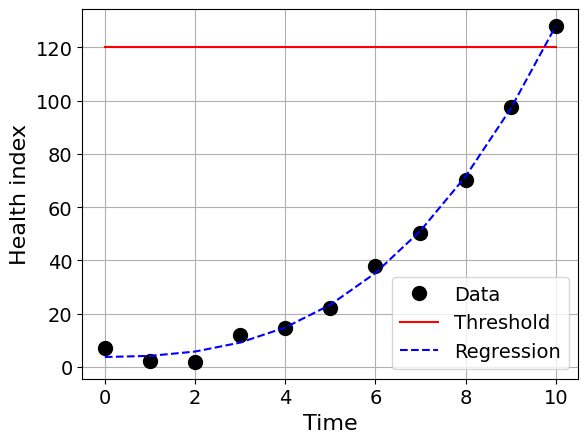

End of Life Time (eolt): 9.759282874085944


In [ ]:
from scipy.optimize import fsolve

hh = np.array([6.99, 2.28, 1.91, 11.94, 14.60, 22.30, 37.85, 50.20, 70.18, 97.69, 128.05])
tt = np.arange(len(hh))
thres = 120

nt = len(tt)
F = np.column_stack((np.ones(nt), tt**2, tt**3))

beta = np.linalg.inv(F.T @ F) @ F.T @ hh
hp = F @ beta

betat = np.array([5, 0.2, 0.1])
ht = F @ betat

plt.figure()
plt.plot(tt, hh, '.k', markersize=20, label='Data')
plt.plot([0, tt[-1]], [thres, thres], 'r', label='Threshold')
plt.plot(tt, hp, '--b', label='Regression')
# plt.plot(tt, ht, 'k', label='True')

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Health index')
plt.legend()

plt.show()

# Residual of (threshold - fitted HI); its root is the predicted EOL time.
def eolFuc(t):
    return thres - (beta[0] + beta[1] * t**2 + beta[2] * t**3)

eolt = fsolve(eolFuc, 100)[0]

print(f"End of Life Time (eolt): {eolt}")

### Prognosis by nonlin reg

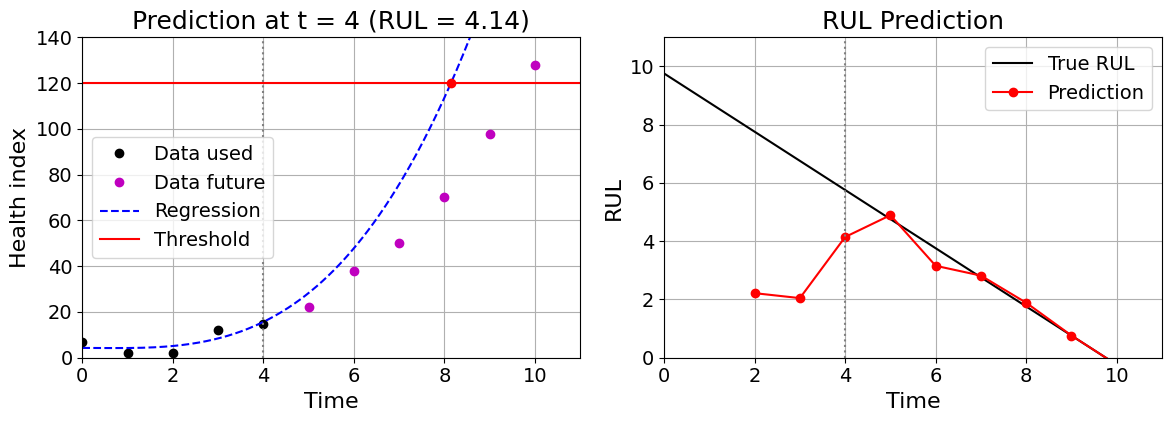

Predicted EOL at t=4: 8.145
Predicted RUL at t=4: 4.145
Full-data EOL: 9.759


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

hh = np.array([6.99, 2.28, 1.91, 11.94, 14.60, 22.30, 37.85, 50.20, 70.18, 97.69, 128.05])
tt = np.arange(len(hh))
thres = 120

# Least-squares cubic fit using the first k points; returns (coeffs, EOL).
def fit_nonlinear(k):
    F = np.column_stack((np.ones(k), tt[:k]**2, tt[:k]**3))
    beta = np.linalg.lstsq(F, hh[:k], rcond=None)[0]
    eol = fsolve(lambda t: thres - (beta[0] + beta[1]*t**2 + beta[2]*t**3), 10)[0]
    return beta, eol

beta_full, eolt = fit_nonlinear(len(hh))

# Sequential RUL prediction
rul = np.full(len(tt), np.nan)
k_values = np.arange(3, len(tt)+1)
for k in k_values:
    beta, eol = fit_nonlinear(k)
    rul[k-1] = eol - tt[k-1]

# Representative prediction at t = 4
current_time = 4
k_show = current_time + 1
beta_show, eol_show = fit_nonlinear(k_show)
tp = np.linspace(0, max(tt[-1], eol_show) + 0.5, 500)
yp = beta_show[0] + beta_show[1]*tp**2 + beta_show[2]*tp**3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(tt[:k_show], hh[:k_show], 'ko', label='Data used')
axes[0].plot(tt[k_show:], hh[k_show:], 'mo', label='Data future')
axes[0].plot(tp, yp, '--b', label='Regression')
axes[0].axhline(thres, color='r', label='Threshold')
axes[0].plot(eol_show, thres, 'ro')
axes[0].axvline(current_time, color='gray', linestyle=':')
axes[0].set_xlim(0, 11)
axes[0].set_ylim(0, 140)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Health index')
axes[0].set_title(f'Prediction at t = {current_time} (RUL = {eol_show-current_time:.2f})')
axes[0].grid(True)
axes[0].legend()

valid = ~np.isnan(rul)
axes[1].plot(tt, eolt - tt, 'k', label='True RUL')
axes[1].plot(tt[valid], rul[valid], 'ro-', label='Prediction')
axes[1].axvline(current_time, color='gray', linestyle=':')
axes[1].set_xlim(0, 11)
axes[1].set_ylim(0, 11)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RUL')
axes[1].set_title('RUL Prediction')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Predicted EOL at t={current_time}: {eol_show:.3f}')
print(f'Predicted RUL at t={current_time}: {eol_show-current_time:.3f}')
print(f'Full-data EOL: {eolt:.3f}')

### Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.subplots_adjust(
    left=0.07, right=0.98,
    bottom=0.14, top=0.90,
    wspace=0.16)

# Animation frame: nonlinear-regression RUL prediction using the first k_values[frame] points.
def update(frame):
    k = k_values[frame]
    current_time = tt[k-1]
    beta, eol = fit_nonlinear(k)
    tp = np.linspace(0, max(tt[-1], eol) + 0.5, 500)
    yp = beta[0] + beta[1]*tp**2 + beta[2]*tp**3

    axes[0].clear()
    axes[0].plot(tt[:k], hh[:k], 'ko', label='Data used')
    axes[0].plot(tt[k:], hh[k:], 'mo', label='Data future')
    axes[0].plot(tp, yp, '--b', label='Regression')
    axes[0].axhline(thres, color='r', label='Threshold')
    axes[0].plot(eol, thres, 'ro')
    axes[0].axvline(current_time, color='gray', linestyle=':')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Health index')
    axes[0].set_title(f'Prediction at t = {current_time} (RUL = {eol-current_time:.2f})')
    axes[0].set_ylim(0, 140)
    axes[0].grid(True)
    axes[0].legend()

    shown = tt <= current_time
    valid = shown & ~np.isnan(rul)
    axes[1].clear()
    axes[1].plot(tt, eolt - tt, 'k', label='True RUL')
    axes[1].plot(tt[valid], rul[valid], 'ro-', label='Prediction')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('RUL')
    axes[1].set_title('RUL Prediction')
    axes[1].grid(True)
    axes[1].legend()

anim = FuncAnimation(fig, update, frames=len(k_values), interval=1000, repeat=False)
# plt.tight_layout()
plt.close(fig)
display(HTML(anim.to_jshtml()))
# gif = "/content/drive/MyDrive/PHM Practice/nonlin_regression_rul_animation.gif"
# anim.save(gif, writer='pillow', fps=1)

## Prognostics metrics

PH = 2.759282874086546


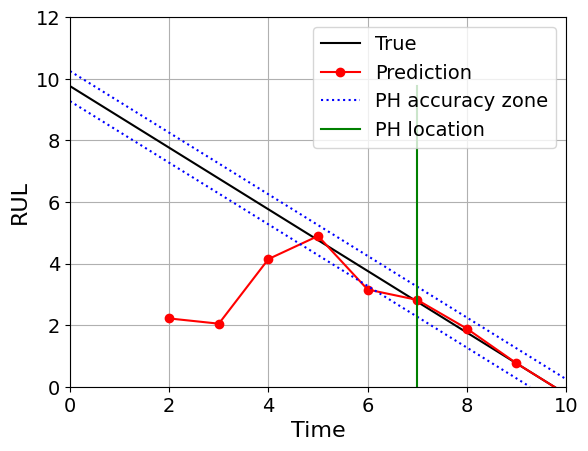

ALA: False


/tmp/ipykernel_2066/956588032.py:43: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  a = np.where((rul[idx_lam] > rult[idx_lam] * (1 - alpha)) &


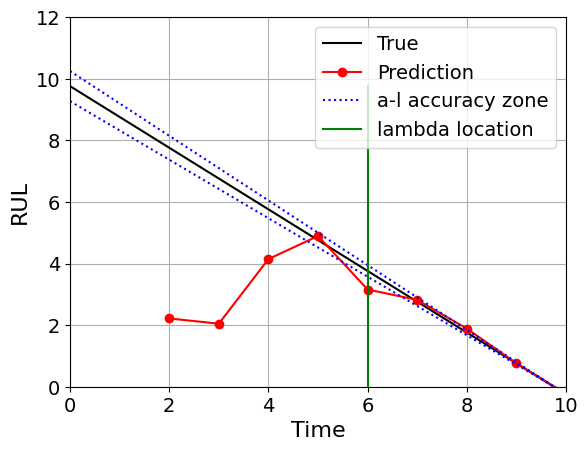

t_lamda: 6
RUL prediction: 3.16
Upper limit: 3.95
Lower limit: 3.57


In [ ]:
alpha = 0.05
ts = 2
lambda_val = 0.5
alphaZone = eolt * alpha

rult = eolt - tt

loca = np.where((rult - alphaZone < rul) & (rul < rult + alphaZone))[0]

diff_loca = np.diff(loca)
a_indices = np.where(np.concatenate(([0], diff_loca)) > 1)[0]

if len(a_indices) > 0:
    a = a_indices[-1]
else:
    a = 0

ph = eolt - tt[loca[a]]
print(f"PH = {ph}")

plt.figure()
plt.plot(tt, eolt - tt, 'k', label='True')
plt.plot(tt[rul != 0], rul[rul != 0], 'ro-', label='Prediction')
plt.grid(True)

plt.plot([0, eolt + alphaZone, np.inf, 0, eolt - alphaZone],
         [eolt + alphaZone, 0, np.inf, eolt - alphaZone, 0], ':b', label='PH accuracy zone')

if len(loca) > 0:
    plt.plot([tt[loca[a]], tt[loca[a]]], [0, eolt], 'g', label='PH location')

plt.xlim(0, tt[-1])
plt.ylim(0, 12)
plt.xlabel('Time')
plt.ylabel('RUL')
plt.legend(loc='best')

plt.show()

t_lam = ts + (eolt - ts) * lambda_val
idx_lam = np.argmin(np.abs(tt - t_lam))
t_lam = tt[idx_lam]
a = np.where((rul[idx_lam] > rult[idx_lam] * (1 - alpha)) &
(rul[idx_lam] < rult[idx_lam] * (1 + alpha)))[0]
if len(a) == 0:
    print('ALA: False')
else:
    print('ALA: True')

plt.figure()
plt.plot(tt, eolt - tt, 'k', tt[rul != 0], rul[rul != 0], 'ro-')
plt.grid(True)
plt.plot(np.concatenate([tt, [np.inf], tt]),
np.concatenate([rult * (1 + alpha), [np.inf], rult * (1 - alpha)]), ':b')
plt.plot([t_lam, t_lam], [0, eolt], 'g')
plt.xlim(0, tt[-1])
plt.ylim(0, 12)
plt.xlabel('Time')
plt.ylabel('RUL')
plt.legend(['True', 'Prediction', 'a-l accuracy zone', 'lambda location'])
plt.show()

print(f"t_lamda: {t_lam}")
print(f"RUL prediction: {rul[idx_lam]:.2f}")
print(f"Upper limit: {rult[idx_lam] * (1 + alpha):.2f}")
print(f"Lower limit: {rult[idx_lam] * (1 - alpha):.2f}")

## Probabilistic linear regression

### Linear regression

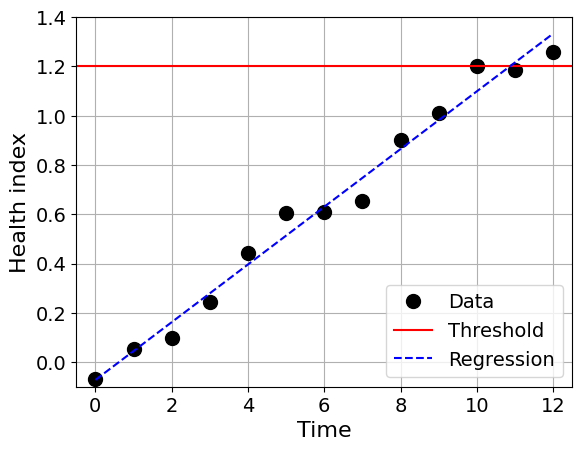

beta: [-0.07245495  0.11714505]
beta std: [0.03356854 0.00474731]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

# ------------------------------------------------------------
# Data: 13 measurements
# ------------------------------------------------------------
yy = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586
])
n = len(yy)
tt = np.arange(n)   # 0, 1, 2, ..., 12

nt = len(tt)
thres = 1.2

F = np.column_stack((np.ones(nt), tt))
beta = np.linalg.lstsq(F, yy, rcond=None)[0]
yh = F @ beta

plt.figure()
plt.plot(tt, yy, '.k', markersize=20)
plt.grid(True)
plt.plot([-.5, 12.5], [thres, thres], 'r')
plt.plot(tt, yh, '--b')
plt.xlabel('Time')
plt.ylabel('Health index')
plt.legend(['Data', 'Threshold', 'Regression'])
plt.axis([-0.5, 12.5, -0.1, 1.4])
plt.show()

eolFuc = lambda t: thres - (beta[0] + beta[1] * t)
eolt = fsolve(eolFuc, 0)[0]

SSe = np.sum((yy - yh)**2)
sig2 = SSe/(nt-2)
bcov = sig2 * np.linalg.inv(F.T @ F)
bstd = np.sqrt(np.diag(bcov))

print(f"beta: {beta}")
print(f"beta std: {bstd}")

### Uncertainty of coefficients

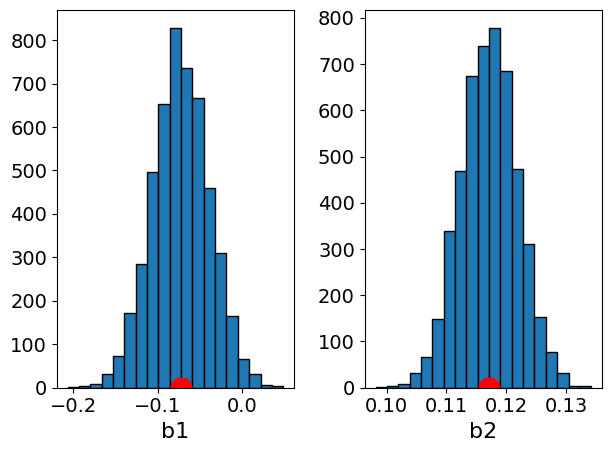

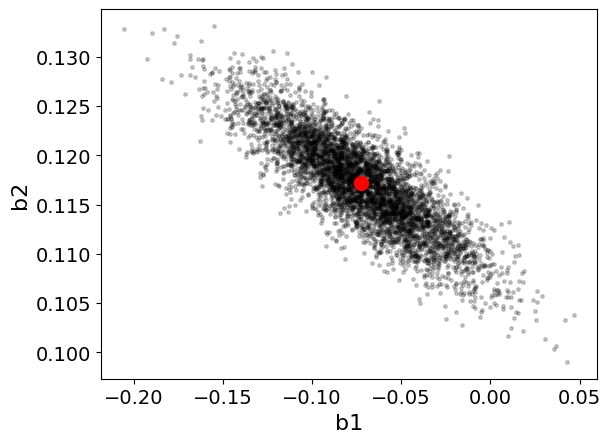

In [ ]:
ns = 5000 # num. of samples

betas = np.random.multivariate_normal(beta, bcov, ns)

plt.figure()
for i in range(2):
    lb = beta[i] - 4 * bstd[i]
    ub = beta[i] + 4 * bstd[i]
    db = (ub - lb) / 20
    plt.subplot(1, 2, i+1)
    plt.hist(betas[:, i], bins=np.arange(lb, ub, db), edgecolor='black')
    plt.xlabel(f'b{i+1}')
    plt.plot(beta[i], 0, 'ro', markersize=15)
plt.tight_layout()

plt.figure()
plt.plot(betas[:, 0], betas[:, 1], '.k', markersize=5, alpha=0.2)
plt.plot(beta[0], beta[1], 'ro', markersize=10)
plt.xlabel('b1')
plt.ylabel('b2')
plt.show()

### Random sampling of linear regression

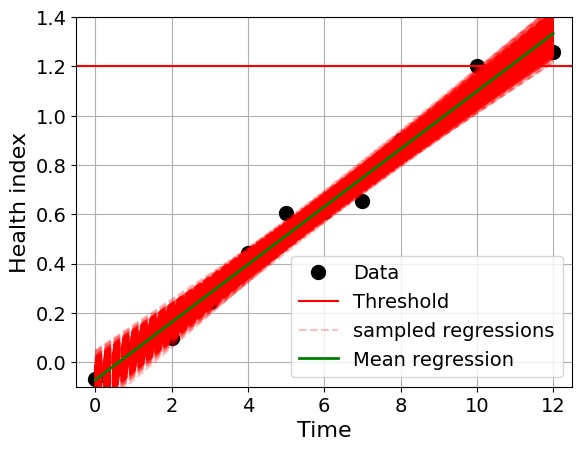

In [ ]:
import numpy as np

n_show = 5000

idx_show = np.random.choice(betas.shape[0], size=n_show, replace=False)
betas_show = betas[idx_show, :]   # shape = (50, 2)

# F: (N,2), betas_show.T: (2,50) -> yh_show: (N,50)
yh_show = F @ betas_show.T

yh_mean = F @ beta

plt.figure()

plt.plot(tt, yy, '.k', markersize=20, label='Data')
plt.plot([-.5, 12.5], [thres, thres], 'r', label='Threshold')

for i in range(n_show):
    if i == 0:
        plt.plot(tt, yh_show[:, i], '--r', alpha=0.25, label='sampled regressions')
    else:
        plt.plot(tt, yh_show[:, i], '--r', alpha=0.25)

plt.plot(tt, yh_mean, '-g', linewidth=2, label='Mean regression')

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Health index')
plt.legend()
plt.axis([-0.5, 12.5, -0.1, 1.4])
plt.show()

### CI using samples percentiles

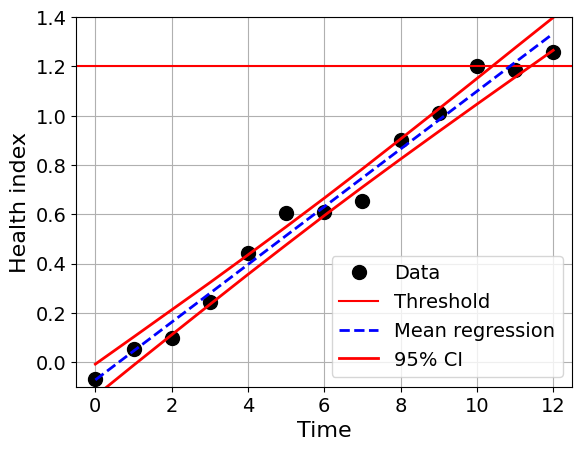

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CI from sampled regressions
ci_lower = np.percentile(yh_show, 2.5, axis=1)
ci_upper = np.percentile(yh_show, 97.5, axis=1)

plt.figure()

plt.plot(tt, yy, '.k', markersize=20, label='Data')
plt.plot([-.5, 12.5], [thres, thres], 'r', label='Threshold')

plt.plot(tt, yh_mean, '--b', linewidth=2, label='Mean regression')
plt.plot(tt, ci_lower, '-r', linewidth=2, label='95% CI')
plt.plot(tt, ci_upper, '-r', linewidth=2)

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Health index')
plt.legend()
plt.axis([-0.5, 12.5, -0.1, 1.4])
plt.show()

### CI & PI using analytic equations

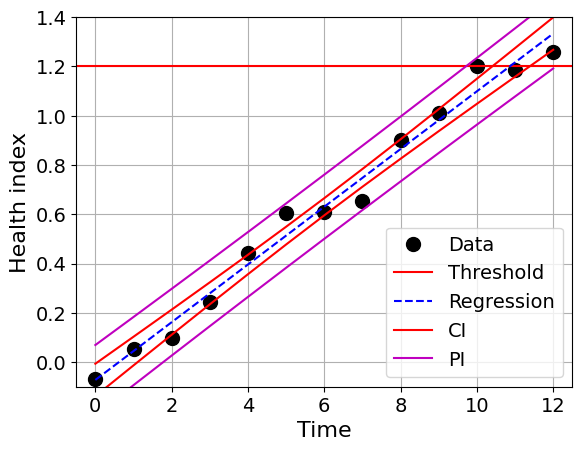

In [ ]:
from scipy import stats

plt.figure()
plt.plot(tt, yy, '.k', markersize=20)
plt.grid(True)
plt.plot([-0.5, 12.5], [thres, thres], 'r')
plt.plot(tt, yh, '--b')
plt.xlabel('Time')
plt.ylabel('Health index')
plt.axis([-0.5, 12.5, -0.1, 1.4])

SSe = np.sum((yy - yh)**2)
sig2 = SSe/(nt-2)
bcov = np.linalg.inv(F.T @ F) * sig2
yhstd = np.sqrt(np.diag(F @ bcov @ F.T))
z_value = stats.norm.ppf(0.975)

ypstd = np.sqrt(np.diag(F @ bcov @ F.T) + sig2)

plt.plot(tt, (yh.T + z_value * yhstd).T, 'r')
plt.plot(tt, (yh.T + z_value * ypstd).T, 'm')
plt.plot(tt, (yh.T - z_value * yhstd).T, 'r')
plt.plot(tt, (yh.T - z_value * ypstd).T, 'm')


plt.legend(['Data', 'Threshold', 'Regression', 'CI', 'PI'])
plt.show()

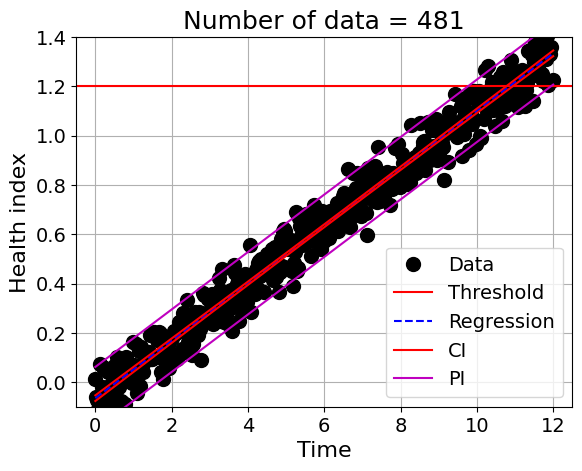

In [ ]:
# repeat with increased data

yy = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586
])
n = len(yy)
tt = np.arange(n)   # 0, 1, 2, ..., 12

nt = len(tt)

mult = 40
tt = np.linspace(tt[0], tt[-1], mult*(nt-1)+1)
tt = tt.reshape(-1, 1)
nt = len(tt)

yy = beta[0] + beta[1]*tt + np.sqrt(sig2)*np.random.randn(nt, 1)

F = np.column_stack((np.ones(nt), tt))
beta = np.linalg.lstsq(F, yy, rcond=None)[0]
yh = F @ beta

plt.figure()
plt.plot(tt, yy, '.k', markersize=20)
plt.grid(True)
plt.plot([-.5, 12.5], [thres, thres], 'r')
plt.plot(tt, yh, '--b')
plt.xlabel('Time')
plt.ylabel('Health index')
plt.axis([-0.5, 12.5, -0.1, 1.4])

SSe = np.sum((yy - yh)**2)
sig2 = SSe/(nt-2)
bcov = np.linalg.inv(F.T @ F) * sig2
yhstd = np.sqrt(np.diag(F @ bcov @ F.T))
z_value = stats.norm.ppf(0.975)

ypstd = np.sqrt(np.diag(F @ bcov @ F.T) + sig2)

plt.plot(tt, (yh.T + z_value * yhstd).T, 'r')
plt.plot(tt, (yh.T + z_value * ypstd).T, 'm')
plt.plot(tt, (yh.T - z_value * yhstd).T, 'r')
plt.plot(tt, (yh.T - z_value * ypstd).T, 'm')


plt.legend(['Data', 'Threshold', 'Regression', 'CI', 'PI'])
plt.title(f'Number of data = {nt}')
plt.show()

## Prob prognosis by linear regression

### Probabilistic prognosis

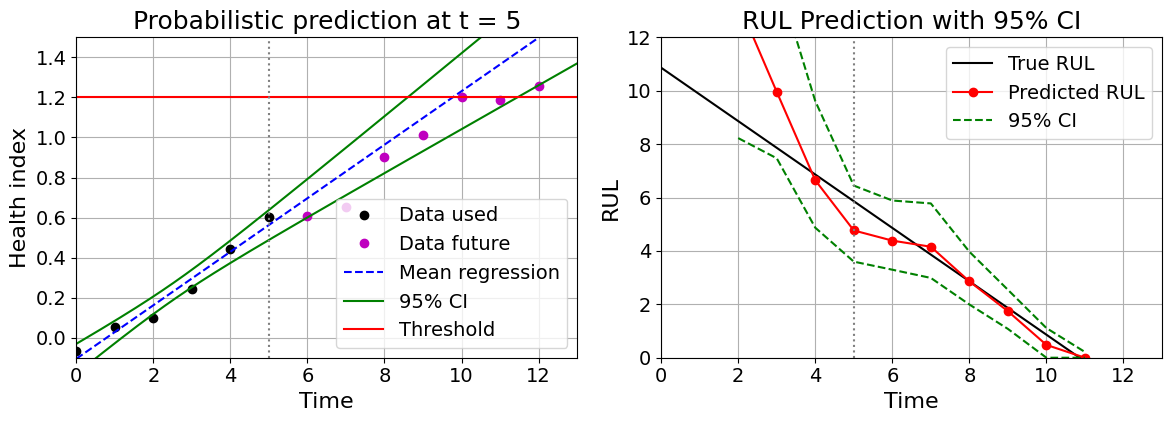

RUL at t=5: 4.767
95% CI: [3.599, 6.447]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data
y = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586
])
time = np.arange(len(y))
threshold = 1.2
z_value = stats.norm.ppf(0.975)

# first_crossing() is defined once, in the Settings and Utilities cell.

def fit_prob_linear(k):
    tk, yk = time[:k], y[:k]
    F = np.column_stack((np.ones(k), tk))
    beta = np.linalg.lstsq(F, yk, rcond=None)[0]
    fit = F @ beta
    sig2 = np.sum((yk - fit)**2) / (k - 2)
    bcov = sig2 * np.linalg.inv(F.T @ F)
    return beta, bcov

# Full-data EOL used as reference
F_full = np.column_stack((np.ones(len(time)), time))
beta_full = np.linalg.lstsq(F_full, y, rcond=None)[0]
eolt = (threshold - beta_full[0]) / beta_full[1]

# Sequential probabilistic RUL prediction
k_values = np.arange(3, len(time))
rul = np.full(len(time), np.nan)
rul_lower = np.full(len(time), np.nan)
rul_upper = np.full(len(time), np.nan)

for k in k_values:
    current_time = time[k-1]
    beta, bcov = fit_prob_linear(k)
    tp = np.linspace(current_time, 20, 3000)
    Fp = np.column_stack((np.ones(len(tp)), tp))
    yh = Fp @ beta
    yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
    lo = yh - z_value * yh_std
    hi = yh + z_value * yh_std

    rul[k-1] = first_crossing(tp, yh, threshold, current_time)
    rul_lower[k-1] = first_crossing(tp, hi, threshold, current_time)
    rul_upper[k-1] = first_crossing(tp, lo, threshold, current_time)

# Representative prediction at t = 5
current_time = 5
k_show = current_time + 1
beta, bcov = fit_prob_linear(k_show)
tp = np.linspace(0, 20, 3000)
Fp = np.column_stack((np.ones(len(tp)), tp))
yh = Fp @ beta
yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
lo = yh - z_value * yh_std
hi = yh + z_value * yh_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(time[:k_show], y[:k_show], 'ko', label='Data used')
axes[0].plot(time[k_show:], y[k_show:], 'mo', label='Data future')
axes[0].plot(tp, yh, '--b', label='Mean regression')
axes[0].plot(tp, lo, 'g', label='95% CI')
axes[0].plot(tp, hi, 'g')
axes[0].axhline(threshold, color='r', label='Threshold')
axes[0].axvline(current_time, color='gray', linestyle=':')
axes[0].set_xlim(0, 13)
axes[0].set_ylim(-0.1, 1.5)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Health index')
axes[0].set_title(f'Probabilistic prediction at t = {current_time}')
axes[0].grid(True)
axes[0].legend()

valid = ~np.isnan(rul)
axes[1].plot(time, eolt - time, 'k', label='True RUL')
axes[1].plot(time[valid], rul[valid], 'ro-', label='Predicted RUL')
axes[1].plot(time[valid], rul_lower[valid], 'g--', label='95% CI')
axes[1].plot(time[valid], rul_upper[valid], 'g--')
axes[1].axvline(current_time, color='gray', linestyle=':')
axes[1].set_xlim(0, 13)
axes[1].set_ylim(0, 12)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RUL')
axes[1].set_title('RUL Prediction with 95% CI')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

i = current_time
print(f'RUL at t={current_time}: {rul[i]:.3f}')
print(f'95% CI: [{rul_lower[i]:.3f}, {rul_upper[i]:.3f}]')

### Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.subplots_adjust(
    left=0.07, right=0.98,
    bottom=0.14, top=0.90,
    wspace=0.16)

# Animation frame: probabilistic linear-regression RUL prediction at k_values[frame].
def update(frame):
    k = k_values[frame]
    current_time = time[k-1]
    beta, bcov = fit_prob_linear(k)

    tp = np.linspace(0, 20, 3000)
    Fp = np.column_stack((np.ones(len(tp)), tp))
    yh = Fp @ beta
    yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
    lo = yh - z_value * yh_std
    hi = yh + z_value * yh_std

    axes[0].clear()
    axes[0].plot(time[:k], y[:k], 'ko', label='Data used')
    axes[0].plot(time[k:], y[k:], 'mo', label='Data future')
    axes[0].plot(tp, yh, '--b', label='Mean regression')
    axes[0].plot(tp, lo, 'g', label='95% CI')
    axes[0].plot(tp, hi, 'g')
    axes[0].axhline(threshold, color='r', label='Threshold')
    axes[0].axvline(current_time, color='gray', linestyle=':')
    axes[0].set_xlim(0, 13)
    axes[0].set_ylim(-0.1, 1.5)
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Health index')
    axes[0].set_title(f'Probabilistic prediction at t = {current_time}')
    axes[0].grid(True)
    axes[0].legend()

    shown = time <= current_time
    valid = shown & ~np.isnan(rul)
    axes[1].clear()
    axes[1].plot(time, eolt - time, 'k', label='True RUL')
    axes[1].plot(time[valid], rul[valid], 'ro-', label='Predicted RUL')
    axes[1].plot(time[valid], rul_lower[valid], 'g--', label='95% CI')
    axes[1].plot(time[valid], rul_upper[valid], 'g--')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('RUL')
    axes[1].set_title('RUL Prediction with 95% CI')
    axes[1].grid(True)
    axes[1].legend()

anim = FuncAnimation(fig, update, frames=len(k_values), interval=1000, repeat=False)
# plt.tight_layout()
plt.close(fig)
display(HTML(anim.to_jshtml()))
# gif = "/content/drive/MyDrive/PHM Practice/lin_regression_rul_CI_animation.gif"
# anim.save(gif, writer='pillow', fps=1)

## Probabilistic prognosis using nonlinear regression

### Nonlin reg 2 coeffs

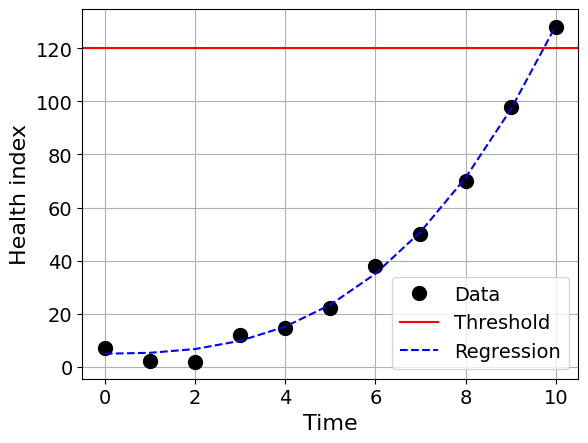

beta: [0.23855469 0.09949953]
beta std: [0.09239853 0.01045564]

End of Life Time (eolt): 9.75303659487442


In [ ]:
import numpy as np
from scipy.optimize import fsolve

yy = np.array([6.99, 2.28, 1.91, 11.94, 14.60, 22.30, 37.85, 50.20, 70.18, 97.69, 128.05]).reshape(-1, 1)
tt = np.arange(len(yy)).reshape(-1, 1)
thres = 120
nt = len(tt)

tp = np.vstack((tt, tt[-1] + np.array([1, 2]).reshape(-1, 1)))
np_len = len(tp)

F = np.hstack((tt**2, tt**3))
beta = np.linalg.lstsq(F, yy-5, rcond=None)[0]
yh = 5 + F @ beta

plt.figure()
plt.plot(tt, yy, '.k', markersize=20)
plt.grid(True)
plt.axhline(thres, c = 'r')
plt.plot(tt, yh, '--b')
plt.xlabel('Time')
plt.ylabel('Health index')
plt.legend(['Data', 'Threshold', 'Regression'])
plt.show()

SSe = np.sum((yy - yh)**2)
sig2 = SSe/(nt-2)
bcov = sig2 * np.linalg.inv(F.T @ F)
bstd = np.sqrt(np.diag(bcov))

print(f"beta: {beta.ravel()}")
print(f"beta std: {bstd}")

# Residual of (threshold - fitted HI); its root is the predicted EOL time.
def eolFuc(t):
    return thres - (5 + beta[0] * t**2 + beta[1] * t**3)

eolt = fsolve(eolFuc, 100)[0]

print()
print(f"End of Life Time (eolt): {eolt}")

### Probabilistic prognosis

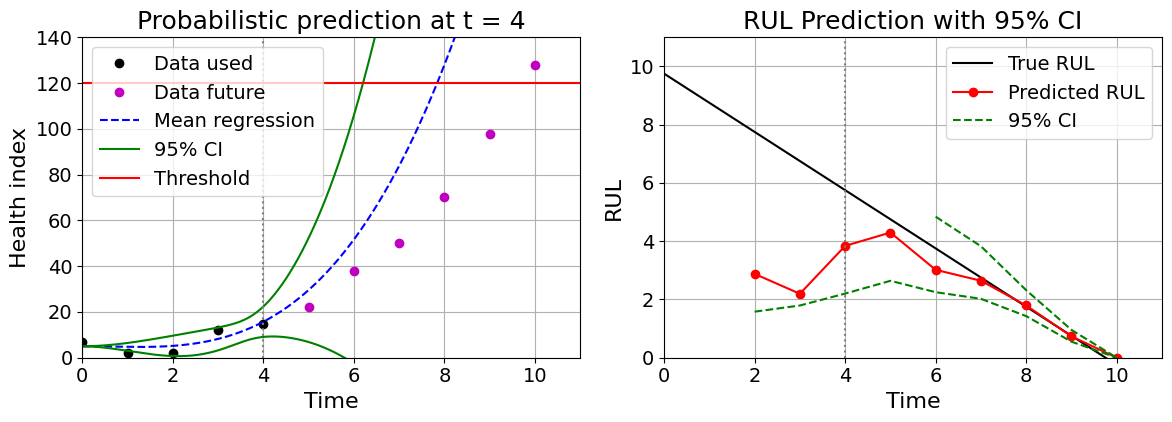

RUL at t=4: 3.840
95% CI: [2.202, nan]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import fsolve

yy = np.array([6.99, 2.28, 1.91, 11.94, 14.60, 22.30, 37.85, 50.20, 70.18, 97.69, 128.05])
tt = np.arange(len(yy))
thres = 120
z_value = stats.norm.ppf(0.975)

# first_crossing() is defined once, in the Settings and Utilities cell.

# Cubic fit with coefficient covariance using the first k points.
def fit_prob_nonlinear(k):
    F = np.column_stack((tt[:k]**2, tt[:k]**3))
    Y = yy[:k] - 5
    beta = np.linalg.lstsq(F, Y, rcond=None)[0]
    fit = 5 + F @ beta
    sig2 = np.sum((yy[:k] - fit)**2) / (k - 2)
    bcov = sig2 * np.linalg.inv(F.T @ F)
    return beta, bcov

# Full-data EOL used as reference
beta_full, _ = fit_prob_nonlinear(len(tt))
eolt = fsolve(lambda t: thres - (5 + beta_full[0]*t**2 + beta_full[1]*t**3), 10)[0]

# Sequential probabilistic RUL prediction
k_values = np.arange(3, len(tt)+1)
rul = np.full(len(tt), np.nan)
rul_lower = np.full(len(tt), np.nan)
rul_upper = np.full(len(tt), np.nan)

for k in k_values:
    current_time = tt[k-1]
    beta, bcov = fit_prob_nonlinear(k)
    tp = np.linspace(current_time, 20, 3000)
    Fp = np.column_stack((tp**2, tp**3))
    yh = 5 + Fp @ beta
    yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
    lo = yh - z_value * yh_std
    hi = yh + z_value * yh_std

    rul[k-1] = first_crossing(tp, yh, thres, current_time)
    rul_lower[k-1] = first_crossing(tp, hi, thres, current_time)
    rul_upper[k-1] = first_crossing(tp, lo, thres, current_time)

# Representative prediction at t
current_time = 4
k_show = current_time + 1
beta, bcov = fit_prob_nonlinear(k_show)
tp = np.linspace(0, 20, 3000)
Fp = np.column_stack((tp**2, tp**3))
yh = 5 + Fp @ beta
yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
lo = yh - z_value * yh_std
hi = yh + z_value * yh_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(tt[:k_show], yy[:k_show], 'ko', label='Data used')
axes[0].plot(tt[k_show:], yy[k_show:], 'mo', label='Data future')
axes[0].plot(tp, yh, '--b', label='Mean regression')
axes[0].plot(tp, lo, 'g', label='95% CI')
axes[0].plot(tp, hi, 'g')
axes[0].axhline(thres, color='r', label='Threshold')
axes[0].axvline(current_time, color='gray', linestyle=':')
axes[0].set_xlim(0, 11)
axes[0].set_ylim(0, 140)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Health index')
axes[0].set_title(f'Probabilistic prediction at t = {current_time}')
axes[0].grid(True)
axes[0].legend()

valid = ~np.isnan(rul)
axes[1].plot(tt, eolt - tt, 'k', label='True RUL')
axes[1].plot(tt[valid], rul[valid], 'ro-', label='Predicted RUL')
axes[1].plot(tt[valid], rul_lower[valid], 'g--', label='95% CI')
axes[1].plot(tt[valid], rul_upper[valid], 'g--')
axes[1].axvline(current_time, color='gray', linestyle=':')
axes[1].set_xlim(0, 11)
axes[1].set_ylim(0, 11)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RUL')
axes[1].set_title('RUL Prediction with 95% CI')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

i = current_time
print(f'RUL at t={current_time}: {rul[i]:.3f}')
print(f'95% CI: [{rul_lower[i]:.3f}, {rul_upper[i]:.3f}]')

### Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.subplots_adjust(
    left=0.07, right=0.98,
    bottom=0.14, top=0.90,
    wspace=0.16)

# Animation frame: probabilistic nonlinear-regression RUL prediction at k_values[frame].
def update(frame):
    k = k_values[frame]
    current_time = tt[k-1]
    beta, bcov = fit_prob_nonlinear(k)

    tp = np.linspace(0, 20, 3000)
    Fp = np.column_stack((tp**2, tp**3))
    yh = 5 + Fp @ beta
    yh_std = np.sqrt(np.diag(Fp @ bcov @ Fp.T))
    lo = yh - z_value * yh_std
    hi = yh + z_value * yh_std

    axes[0].clear()
    axes[0].plot(tt[:k], yy[:k], 'ko', label='Data used')
    axes[0].plot(tt[k:], yy[k:], 'mo', label='Data future')
    axes[0].plot(tp, yh, '--b', label='Mean regression')
    axes[0].plot(tp, lo, 'g', label='95% CI')
    axes[0].plot(tp, hi, 'g')
    axes[0].axhline(thres, color='r', label='Threshold')
    axes[0].axvline(current_time, color='gray', linestyle=':')
    axes[0].set_xlim(0, 11)
    axes[0].set_ylim(0, 140)
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Health index')
    axes[0].set_title(f'Probabilistic prediction at t = {current_time}')
    axes[0].grid(True)
    axes[0].legend()

    shown = tt <= current_time
    valid = shown & ~np.isnan(rul)
    axes[1].clear()
    axes[1].plot(tt, eolt - tt, 'k', label='True RUL')
    axes[1].plot(tt[valid], rul[valid], 'ro-', label='Predicted RUL')
    axes[1].plot(tt[valid], rul_lower[valid], 'g--', label='95% CI')
    axes[1].plot(tt[valid], rul_upper[valid], 'g--')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('RUL')
    axes[1].set_title('RUL Prediction with 95% CI')
    axes[1].grid(True)
    axes[1].legend()

anim = FuncAnimation(fig, update, frames=len(k_values), interval=1000, repeat=False)
gif = "/content/drive/MyDrive/PHM Practice/nonlin_regression_rul_CI_animation.gif"
# plt.tight_layout()
plt.close(fig)
display(HTML(anim.to_jshtml()))
anim.save(gif, writer='pillow', fps=1)

## Real prognosis of bearing

### 1. Load features and construct HI by regression

Dataset       = IMS_1st_ch5
Test EOL      = 1977
Prognostic EOL= 1957
Normal reference N = 20
Fault reference N  = 20
HI = -2.2274 + 14.46 RMS + 0 BPFO + 0 BPFI


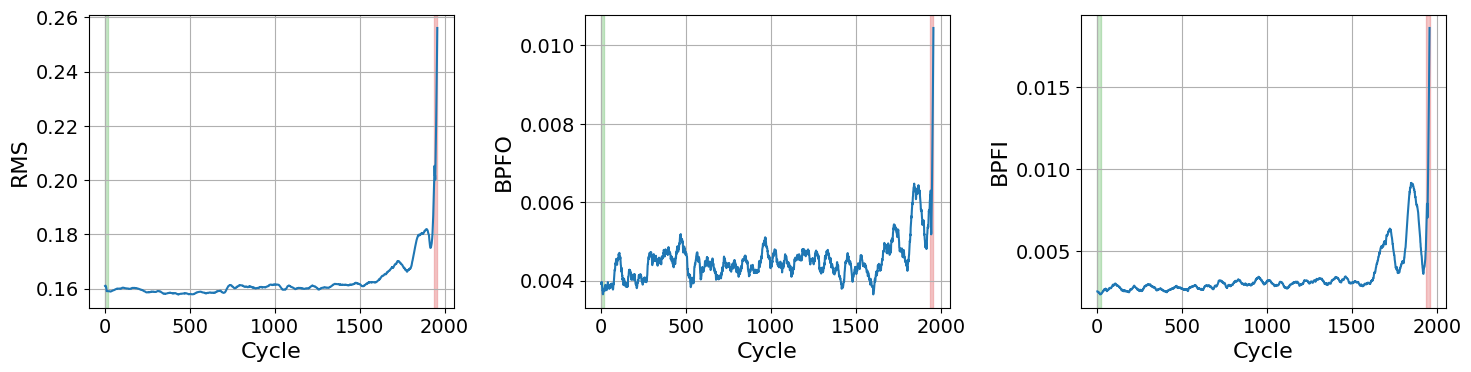

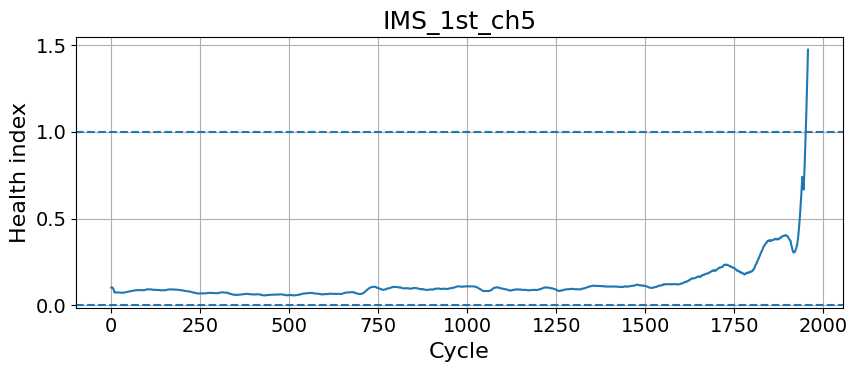

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# from sklearn.linear_model import LinearRegression

# # ============================================================
# # Select dataset
# # ============================================================
# dataset = 'IMS_1st_ch5'

# csv_paths = {
#     'IMS_2nd_ch1': DATA_ROOT / 'Bearing_IMS' / 'IMS_2nd_ch1_features.csv',
#     'IMS_1st_ch5': DATA_ROOT / 'Bearing_IMS' / 'IMS_1st_ch5_features.csv',
#     'd1_x': DATA_ROOT / 'Bearing_FEMTO' / 'd1_x_features.csv',
#     'd4_x': DATA_ROOT / 'Bearing_FEMTO' / 'd4_x_features.csv',
#     'XJTU_2_1_ch2': DATA_ROOT / 'Bearing_XJTU_SY' / 'XJTU_2_1_ch2_features.csv',
#     'XJTU_2_5_ch2': DATA_ROOT / 'Bearing_XJTU_SY' / 'XJTU_2_5_ch2_features.csv'
# }

# df = pd.read_csv(csv_paths[dataset])

# cycle_all = df['Cycle'].to_numpy()

# X_all = df[
#     ['RMS_smoothed', 'BPFO_smoothed', 'BPFI_smoothed']
# ].to_numpy()

# # ============================================================
# # Remove initial baseline shift for IMS_1st_ch5
# # ============================================================
# if dataset == 'IMS_1st_ch5':
#     start_cycle = 180

#     mask = cycle_all >= start_cycle
#     cycle_all = cycle_all[mask]
#     X_all = X_all[mask]

#     cycle_all = np.arange(1, len(cycle_all) + 1)

# # ============================================================
# # Prognostic EOL: remove final 1%
# # ============================================================
# n_total = len(cycle_all)
# n_remove = int(np.ceil(0.01 * n_total)) # original 0.01, d1_x, XJTU_2_1_ch2 0.02
# n_keep = n_total - n_remove

# cycle = cycle_all[:n_keep]
# X = X_all[:n_keep]

# eol = cycle[-1]

# # ============================================================
# # HI reference regions
# # ============================================================
# n_normal = max(20, int(np.ceil(0.01 * n_keep)))
# n_fault = max(20, int(np.ceil(0.01 * n_keep)))

# X_ref = np.vstack([
#     X[:n_normal],
#     X[-n_fault:]
# ])

# HI_ref = np.hstack([
#     np.zeros(n_normal),
#     np.ones(n_fault)
# ])

# hi_model = LinearRegression(positive=True) # original: positive=True
# hi_model.fit(X_ref, HI_ref)

# HI = hi_model.predict(X)

# print('Dataset       =', dataset)
# print('Test EOL      =', cycle_all[-1])
# print('Prognostic EOL=', eol)
# print('Normal reference N =', n_normal)
# print('Fault reference N  =', n_fault)

# print(
#     'HI = '
#     f'{hi_model.intercept_:.4f} '
#     f'+ {hi_model.coef_[0]:.4g} RMS '
#     f'+ {hi_model.coef_[1]:.4g} BPFO '
#     f'+ {hi_model.coef_[2]:.4g} BPFI'
# )

# feature_names = ['RMS_smoothed', 'BPFO_smoothed', 'BPFI_smoothed']
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# for ax, feature, values in zip(axes, feature_names, X.T):
#     ax.plot(cycle, values)
#     ax.axvspan(cycle[0], cycle[n_normal - 1], color='tab:green', alpha=0.25)
#     ax.axvspan(cycle[-n_fault], cycle[-1], color='tab:red', alpha=0.25)
#     ax.set_xlabel('Cycle')
#     ax.set_ylabel(feature.replace('_smoothed', ''))
#     ax.grid(True)

# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(9, 4))
# plt.plot(cycle, HI)
# plt.axhline(0, linestyle='--')
# plt.axhline(1, linestyle='--')
# plt.xlabel('Cycle')
# plt.ylabel('Health index')
# plt.title(dataset)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

### 1. Load features and construct HI

Dataset       = d4_x
Test EOL      = 1428
Prognostic EOL= 1413
Normal reference N = 20
Fault reference N  = 20
Feature changes = [1603.35457192  398.14230857 2214.36889084]
Feature weights = [0.38031443 0.09443904 0.52524654]
HI = -0.0321 + 0.03792 RMS + 0.02105 BPFO + 0.6005 BPFI


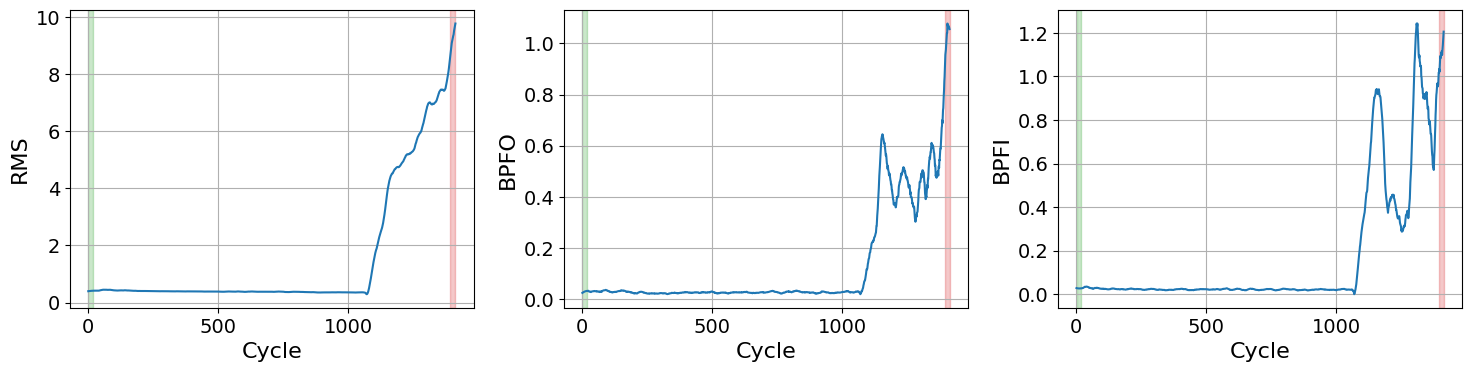

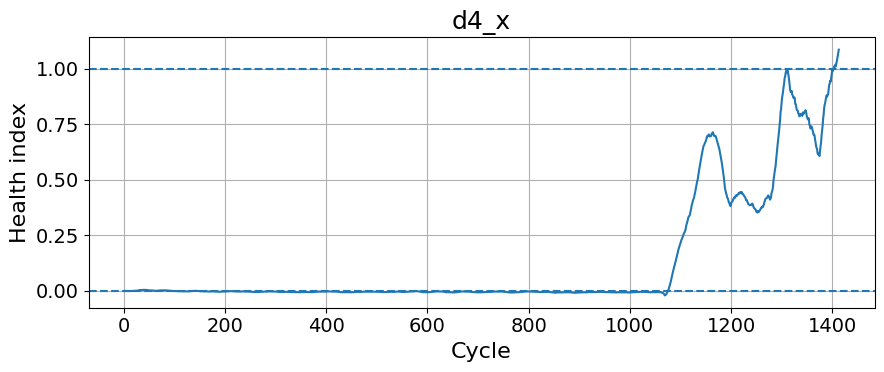

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Select dataset
# ============================================================
dataset = 'd4_x'

csv_paths = {
    'IMS_2nd_ch1': DATA_ROOT / 'Bearing_IMS' / 'IMS_2nd_ch1_features.csv',
    'IMS_1st_ch5': DATA_ROOT / 'Bearing_IMS' / 'IMS_1st_ch5_features.csv',
    'd1_x': DATA_ROOT / 'Bearing_FEMTO' / 'd1_x_features.csv',
    'd4_x': DATA_ROOT / 'Bearing_FEMTO' / 'd4_x_features.csv',
    'XJTU_2_1_ch2': DATA_ROOT / 'Bearing_XJTU_SY' / 'XJTU_2_1_ch2_features.csv',
    'XJTU_2_5_ch2': DATA_ROOT / 'Bearing_XJTU_SY' / 'XJTU_2_5_ch2_features.csv'
}

df = pd.read_csv(csv_paths[dataset])
cycle_all = df['Cycle'].to_numpy()

feature_names = ['RMS_smoothed', 'BPFO_smoothed', 'BPFI_smoothed']
X_all = df[feature_names].to_numpy()

# ============================================================
# Remove initial baseline shift for IMS_1st_ch5
# ============================================================
if dataset == 'IMS_1st_ch5':
    start_cycle = 180
    mask = cycle_all >= start_cycle
    cycle_all = cycle_all[mask]
    X_all = X_all[mask]
    cycle_all = np.arange(1, len(cycle_all) + 1)

# ============================================================
# Prognostic EOL: remove final 1%
# ============================================================
n_total = len(cycle_all)
n_remove = int(np.ceil(0.01 * n_total)) # d4_x IMS_2nd_ch1 IMS_1st_ch5 XJTU_2_1_ch2 XJTU_2_5_ch2 0.01; d1_x 0.02
n_keep = n_total - n_remove

cycle = cycle_all[:n_keep]
X = X_all[:n_keep]
eol = cycle[-1]

# ============================================================
# HI reference regions
# ============================================================
n_normal = max(20, int(np.ceil(0.01 * n_keep)))
n_fault = max(20, int(np.ceil(0.01 * n_keep)))

# Standardize features using the normal region
x_normal_mean = X[:n_normal].mean(axis=0)
x_normal_std = X[:n_normal].std(axis=0, ddof=1)
x_normal_std = np.maximum(x_normal_std, np.finfo(float).eps)
X_scaled = (X - x_normal_mean) / x_normal_std

# Calculate normal-to-failure feature changes
changes = (
    X_scaled[-n_fault:].mean(axis=0)
    - X_scaled[:n_normal].mean(axis=0)
)

# Relative feature weights with a sum of 1
weights = changes / changes.sum()

# Combined degradation score
z = X_scaled @ weights
z_normal = z[:n_normal].mean()
z_fault = z[-n_fault:].mean()
HI = (z - z_normal) / (z_fault - z_normal)

# Equivalent HI equation in the original feature units
hi_coef = (weights / x_normal_std) / (z_fault - z_normal)
hi_intercept = (
    -np.sum(weights * x_normal_mean / x_normal_std) - z_normal
) / (z_fault - z_normal)

print('Dataset       =', dataset)
print('Test EOL      =', cycle_all[-1])
print('Prognostic EOL=', eol)
print('Normal reference N =', n_normal)
print('Fault reference N  =', n_fault)
print('Feature changes =', changes)
print('Feature weights =', weights)
print(
    'HI = '
    f'{hi_intercept:.4f} '
    f'+ {hi_coef[0]:.4g} RMS '
    f'+ {hi_coef[1]:.4g} BPFO '
    f'+ {hi_coef[2]:.4g} BPFI'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature, values in zip(axes, feature_names, X.T):
    ax.plot(cycle, values)
    ax.axvspan(cycle[0], cycle[n_normal - 1], color='tab:green', alpha=0.25)
    ax.axvspan(cycle[-n_fault], cycle[-1], color='tab:red', alpha=0.25)
    ax.set_xlabel('Cycle')
    ax.set_ylabel(feature.replace('_smoothed', ''))
    ax.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cycle, HI)
plt.axhline(0, linestyle='--')
plt.axhline(1, linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('Health index')
plt.title(dataset)
plt.grid(True)
plt.tight_layout()
plt.show()


### Anomaly detection

Anomaly detected at cycle = 1078
HI at anomaly point = 0.0180
t-statistic = 78.2651
Baseline size = 20
Baseline mean = -0.0000
Baseline std = 0.0002
alpha = 0.01
t critical value = 2.5395
Minimum HI increase = 0.0100
HI threshold = 0.0100


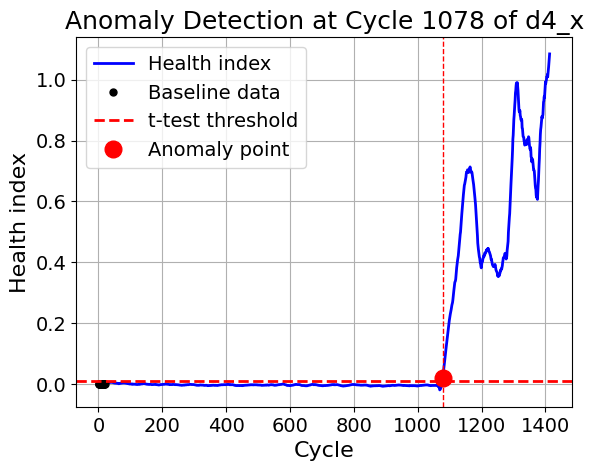

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# HI: health index constructed in the preceding cell
# cycle: cycle index

hi = np.asarray(HI).ravel()
cycle = np.asarray(cycle).ravel()

alpha = 0.01
min_hi_increase = 0.01 # d1_x d4_x IMS_2nd_ch1 XJTU_2_1_ch2 XJTU_2_5_ch2 0.01 IMS_1st_ch5 0.15

# --------------------------------------------------
# 1. Initial 10% as normal baseline
# --------------------------------------------------
n_base = n_normal

hi_base = hi[:n_base]

mu0 = np.mean(hi_base)
std0 = np.std(hi_base, ddof=1)

df = n_base - 1

# One-sided t threshold
t_crit = stats.t.ppf(1 - alpha, df)

# Prediction-type threshold for a new single HI value
t_thres = mu0 + t_crit * std0 * np.sqrt(1 + 1/n_base)
hi_thres = max(t_thres, mu0 + min_hi_increase, 0.0)

# --------------------------------------------------
# 2. t-statistic for each HI point
# --------------------------------------------------
t_stat = (hi - mu0) / (std0 * np.sqrt(1 + 1/n_base))

# Detect first anomaly only after baseline period
# anomaly_idx_all = np.where((np.arange(len(hi)) >= n_base) & (t_stat > t_crit))[0]
above = hi > hi_thres
run = np.convolve(above.astype(int), np.ones(3, dtype=int), 'valid')
anomaly_idx_all = np.where((np.arange(len(run)) >= n_base) & (run == 3))[0]

if len(anomaly_idx_all) > 0:
    anomaly_idx = anomaly_idx_all[0]
    anomaly_cycle = cycle[anomaly_idx]
    anomaly_hi = hi[anomaly_idx]

    print(f"Anomaly detected at cycle = {anomaly_cycle}")
    print(f"HI at anomaly point = {anomaly_hi:.4f}")
    print(f"t-statistic = {t_stat[anomaly_idx]:.4f}")
else:
    anomaly_idx = None
    print("No anomaly detected.")

print(f"Baseline size = {n_base}")
print(f"Baseline mean = {mu0:.4f}")
print(f"Baseline std = {std0:.4f}")
print(f"alpha = {alpha}")
print(f"t critical value = {t_crit:.4f}")
print(f"Minimum HI increase = {min_hi_increase:.4f}")
print(f"HI threshold = {hi_thres:.4f}")

# --------------------------------------------------
# 3. Plot HI vs cycle
# --------------------------------------------------
plt.figure()

plt.plot(cycle, hi, 'b', linewidth=2, label='Health index')
plt.plot(cycle[:n_base], hi[:n_base], 'ko', markersize=5, label='Baseline data')
plt.axhline(hi_thres, color='r', linestyle='--', linewidth=2, label='t-test threshold')

if anomaly_idx is not None:
    plt.plot(cycle[anomaly_idx], hi[anomaly_idx], 'ro', markersize=12, label='Anomaly point')
    plt.axvline(cycle[anomaly_idx], color='r', linestyle='--', linewidth=1)

plt.grid(True)
plt.xlabel('Cycle')
plt.ylabel('Health index')
if anomaly_idx is not None:
    plt.title(f'Anomaly Detection at Cycle {anomaly_cycle:.0f} of {dataset}')
else:
    plt.title(f'No Anomaly Detected in {dataset}')
plt.legend()
plt.show()


### Prognosis by regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy.optimize import curve_fit

cycle, hi = np.asarray(cycle).ravel(), np.asarray(hi).ravel()

# threshold, step_cycle, n_init = 1.0, 50, 5 # fixed interval
threshold, n_frames, n_init = 1.0, 20, 5 # fixed number
ns, tau_scale = 5000, 100.0
model_type = 'exp'  # 'power' or 'exp'
rng = np.random.default_rng(0)
method_label = f'Regression ({model_type})'

t0 = cycle[anomaly_idx]
n_init = min(n_init, len(hi) - anomaly_idx)
HI0 = np.mean(hi[anomaly_idx:anomaly_idx + n_init])

peak_idx = anomaly_idx + np.argmax(hi[anomaly_idx:])
cycle_rtf = cycle[anomaly_idx:peak_idx + 1]
hi_rtf = hi[anomaly_idx:peak_idx + 1]

print(f'Model = {model_type}')
print(f'Anomaly cycle = {t0}')
print(f'Initial HI = {HI0:.4f}')
print(f'Run-to-fail endpoint = {cycle[peak_idx]}')


# Normalized time since the detected anomaly (used as the regression input).
def tau(t):
    return (np.asarray(t) - t0) / tau_scale


# Degradation model evaluated at normalized time x: power law or exponential.
def model(x, b1, b2):
    if model_type == 'power':
        return HI0 + b1 * x**b2
    return HI0 + b1 * (np.exp(b2 * x) - 1)


# Text label of the active degradation model, for plot titles.
def model_label():
    if model_type == 'power':
        return f'HI0 + b1((t-t0)/{tau_scale:.0f})^b2'
    return f'HI0 + b1[exp(b2((t-t0)/{tau_scale:.0f})) - 1]'


# Interpolated time at which curve y first reaches `level`.
def crossing(t, y, level=threshold):
    hit = np.flatnonzero(y >= level)
    if not len(hit):
        return np.nan

    j = hit[0]
    if j == 0:
        return t[0]

    return np.interp(
        level, y[j - 1:j + 1], t[j - 1:j + 1])


# Rough starting values for curve_fit, based on the total rise in y.
def initial_guess(x, y):
    rise = max(y[-1] - HI0, 1e-6)
    x_end = max(x[-1], 1e-6)

    if model_type == 'power':
        return [max(rise / x_end**1.5, 1e-6), 1.5]

    b2 = 0.5
    b1 = rise / max(np.exp(b2 * x_end) - 1, 1e-8)
    return [max(b1, 1e-6), b2]


# Parameter bounds for curve_fit, depending on the active model type.
def bounds():
    if model_type == 'power':
        return [0, 0.1], [np.inf, 6]
    return [0, 0.001], [np.inf, 10]


# Fit the degradation model to data up to the current cycle;
# returns (coefficients, covariance, residual std).
def fit_model(t_used, y_used):
    x = tau(t_used)
    beta, cov = curve_fit(
        model, x, y_used, p0=initial_guess(x, y_used),
        bounds=bounds(), maxfev=20000)

    residual = y_used - model(x, *beta)
    dof = max(len(y_used) - 2, 1)
    sigma = np.sqrt(np.sum(residual**2) / dof)

    if not np.all(np.isfinite(cov)):
        cov = np.diag([1e-8, 1e-4])

    return beta, cov + 1e-12 * np.eye(2), sigma


# Keep only finite, positive samples within the model's parameter bounds.
def valid_samples(samples):
    valid = np.all(np.isfinite(samples), axis=1)
    valid &= np.all(samples > 0, axis=1)

    if model_type == 'power':
        valid &= samples[:, 1] >= 0.1
        valid &= samples[:, 1] <= 6
    else:
        valid &= samples[:, 1] >= 0.001
        valid &= samples[:, 1] <= 10

    return samples[valid]


# EOL time of each sampled curve (columns of `curves`) after `current`.
def sampled_crossings(t, curves, current):
    keep = t >= current
    t, curves = t[keep], curves[keep]
    reached = np.any(curves >= threshold, axis=0)
    curves = curves[:, reached]

    if not curves.shape[1]:
        return np.array([])

    j = np.argmax(curves >= threshold, axis=0)
    cols = np.arange(curves.shape[1])
    j0 = np.maximum(j - 1, 0)

    t0s, t1s = t[j0], t[j]
    y0s, y1s = curves[j0, cols], curves[j, cols]
    den = np.where(y1s != y0s, y1s - y0s, 1)

    eol = t0s + (threshold - y0s) * (t1s - t0s) / den
    eol[j == 0] = t[0]
    return eol


eol_true = crossing(cycle, hi)
print(f'True EOL = {eol_true:.2f}')

# fixed number of regression
step_cycle = max(
    1, int(np.ceil(
        (cycle_rtf[-1] - cycle_rtf[0]) / n_frames)))

frame_cycles = np.arange(
    cycle_rtf[0] + step_cycle,
    cycle_rtf[-1] + step_cycle,
    step_cycle)

frame_indices = np.searchsorted(
    cycle_rtf, frame_cycles, side='right') - 1

frame_indices = np.unique(
    np.clip(frame_indices, 4, len(cycle_rtf) - 1))

results = []

for end_idx in frame_indices:
    t_used = cycle_rtf[:end_idx + 1]
    y_used = hi_rtf[:end_idx + 1]
    current = t_used[-1]

    beta, cov, sigma = fit_model(t_used, y_used)
    grid_end = max(cycle_rtf[-1], current + 500)
    t_grid = np.linspace(t0, grid_end, 1500)
    hi_mean = model(tau(t_grid), *beta)
    eol_point = crossing(t_grid, hi_mean)

    samples = rng.multivariate_normal(beta, cov, ns)
    samples = valid_samples(samples)

    if len(samples) > 20:
        x = tau(t_grid)[:, None]
        b1 = samples[:, 0][None, :]
        b2 = samples[:, 1][None, :]

        if model_type == 'power':
            hi_samples = HI0 + b1 * x**b2
        else:
            hi_samples = HI0 + b1 * (np.exp(b2 * x) - 1)

        noise = rng.normal(0, sigma, hi_samples.shape)
        hi_samples += noise

        hi_low, hi_up = np.percentile(
            hi_samples, [2.5, 97.5], axis=1)

        eol_samples = sampled_crossings(
            t_grid, hi_samples, current)

        if len(eol_samples) > 20:
            eol_low, eol_med, eol_up = np.percentile(
                eol_samples, [2.5, 50, 97.5])
        else:
            eol_med = crossing(t_grid, hi_mean)
            eol_low, eol_up = np.nan, np.nan
    else:
        hi_low = np.full_like(t_grid, np.nan)
        hi_up = np.full_like(t_grid, np.nan)
        eol_med = crossing(t_grid, hi_mean)
        eol_low, eol_up = np.nan, np.nan

    results.append({
        'curr_cycle': current,
        'cycle_used': t_used,
        'hi_used': y_used,
        'beta_hat': beta,
        't_grid': t_grid,
        'hi_mean': hi_mean,
        'hi_low': hi_low,
        'hi_up': hi_up,
        'eol_pred': eol_point,
        'rul_pred': eol_point - current,
        'rul_low': eol_low - current,
        'rul_med': eol_med - current,
        'rul_up': eol_up - current,
        'true_rul': eol_true - current,
        'end_idx': end_idx})


fig, ax = plt.subplots(figsize=(8, 5))

x_max = cycle[-1] * 1.2
y_max = max(1.4, np.nanmax(hi) * 1.05)

# Animation frame: run-to-failure prognosis using data up to results[i].
def update(i):
    ax.clear()

    r = results[i]
    current = r['curr_cycle']
    future = anomaly_idx + r['end_idx'] + 1

    ax.plot(cycle, hi, color='lightgray', linewidth=2, label='Original HI')
    ax.plot(cycle[:anomaly_idx + 1], hi[:anomaly_idx + 1],
            'k.', markersize=5, label='Before anomaly')
    ax.plot(r['cycle_used'], r['hi_used'], 'bo', markersize=5, label='Data used')
    ax.plot(cycle[future:peak_idx + 1], hi[future:peak_idx + 1],
            '.', color='orange', markersize=5, label='Future RTF data')

    if peak_idx + 1 < len(cycle):
        ax.plot(cycle[peak_idx + 1:], hi[peak_idx + 1:],
                'rx', markersize=5, label='Removed descending data')

    ax.plot(r['t_grid'], r['hi_mean'], 'b-', linewidth=2.5, label=f'{model_type} fit')
    ax.plot(r['t_grid'], r['hi_low'], 'g--', linewidth=2, label='95% PI')
    ax.plot(r['t_grid'], r['hi_up'], 'g--', linewidth=2)
    ax.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    ax.axvline(eol_true, color='k', linestyle='--', linewidth=2, label='True EOL')
    ax.axvline(current, color='gray', linestyle=':', linewidth=1.5, label='Current cycle')
    ax.plot(t0, HI0, 'ro', markersize=9, label='Initial HI0')
    ax.plot(r['eol_pred'], threshold, 'ms', markersize=9, label='Predicted EOL')
    ax.axvline(r['eol_pred'], color='m', linestyle='--', linewidth=1.5)

    b1, b2 = r['beta_hat']

    ax.set(xlim=(cycle[0], x_max), ylim=(-0.5, y_max),
           xlabel='Cycle', ylabel='Health index',
           title=(f'Prognosis of {dataset} at cycle = {current:.0f}\n'
                  f'{model_label()}, b1={b1:.3e}, b2={b2:.3f}'))

    eol_text = (
        f'Anomaly detection = {anomaly_cycle:.0f}\n'
        f'Predicted EOL = {r["eol_pred"]:.1f}\n'
        f'True EOL = {eol_true:.1f}')
    ax.text(0.97, 0.25, eol_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray'))
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()

anim = FuncAnimation(
    fig, update, frames=len(results),
    interval=800, repeat=False)

plt.close(fig)
display(HTML(anim.to_jshtml()))

Model = exp
Anomaly cycle = 1078
Initial HI = 0.0348
Run-to-fail endpoint = 1413
True EOL = 1403.08


<Figure size 640x480 with 0 Axes>

### RUL plot

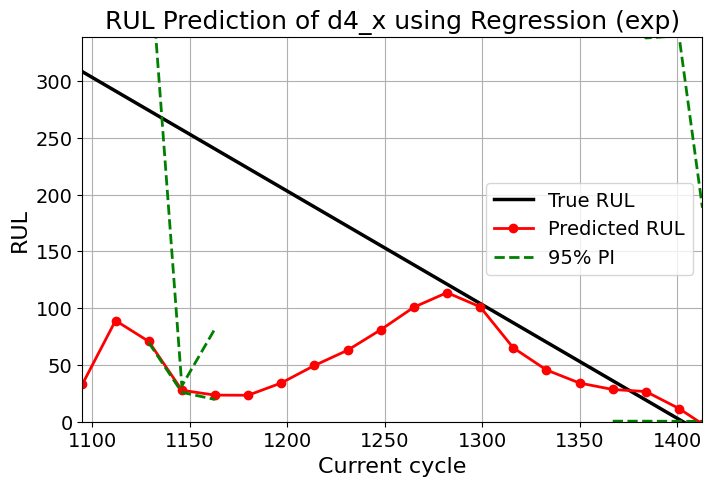

In [ ]:
# --------------------------------------------------
# Automatic fixed axis limits for RUL plot
# --------------------------------------------------

curr_cycles = np.array([r["curr_cycle"] for r in results])
true_rul    = np.array([r["true_rul"] for r in results])
rul_pred    = np.array([r["rul_pred"] for r in results])
rul_low     = np.array([r["rul_low"] for r in results])
rul_up      = np.array([r["rul_up"] for r in results])

x_min = np.nanmin(curr_cycles)
x_max = np.nanmax(curr_cycles)

# y-axis range based on the full set of true/predicted/lower/upper RUL values
all_rul = np.concatenate([
    true_rul[np.isfinite(true_rul)],
    rul_pred[np.isfinite(rul_pred)],
    rul_low[np.isfinite(rul_low)],
    rul_up[np.isfinite(rul_up)]
])

y_min = 0
y_max = np.nanmax(true_rul) * 1.1

# --------------------------------------------------
# 8. RUL plot with 95% CI
# --------------------------------------------------
curr_cycles = np.array([r["curr_cycle"] for r in results])
true_rul = np.array([r["true_rul"] for r in results])

rul_pred = np.array([r["rul_pred"] for r in results])
rul_low = np.array([r["rul_low"] for r in results])
rul_up = np.array([r["rul_up"] for r in results])

plt.figure(figsize=(8, 5))

plt.plot(curr_cycles, true_rul, 'k-', linewidth=2.5, label='True RUL')
plt.plot(curr_cycles, rul_pred, 'ro-', linewidth=2, label='Predicted RUL')
plt.plot(curr_cycles, rul_low, 'g--', linewidth=2, label='95% PI')
plt.plot(curr_cycles, rul_up, 'g--', linewidth=2)

plt.grid(True)
plt.xlabel('Current cycle')
plt.ylabel('RUL')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title(f'RUL Prediction of {dataset} using {method_label}')
plt.legend()
plt.show()

## Sampling fundamentals

### Sampling with built-in function

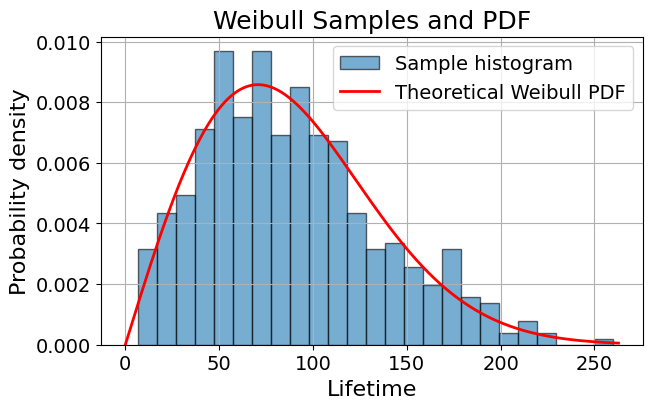

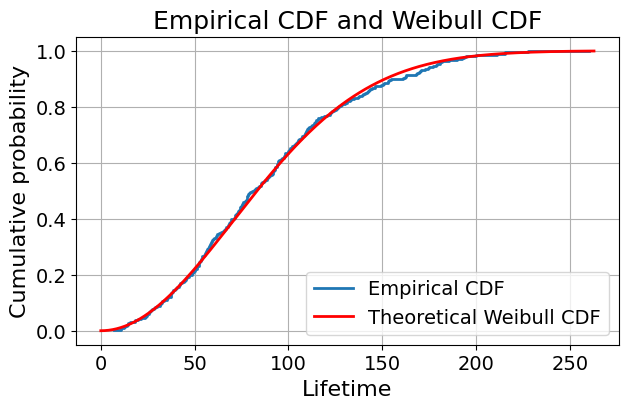

P(T <= 80.0) from samples = 0.4960
P(T <= 80.0) from Weibull CDF = 0.4727

B10 from samples = 32.4876
B10 from Weibull inverse CDF = 32.4593


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# --------------------------------------------------
# Weibull parameters
# --------------------------------------------------
beta = 2.0       # shape parameter
eta = 100.0      # scale parameter

# Number of virtual samples
ns = 500

# Generate Weibull samples
samples = weibull_min.rvs(c=beta, scale=eta, size=ns, random_state=0)

# --------------------------------------------------
# Theoretical PDF and CDF
# --------------------------------------------------
x = np.linspace(0, weibull_min.ppf(0.999, c=beta, scale=eta), 500)

pdf_theory = weibull_min.pdf(x, c=beta, scale=eta)
cdf_theory = weibull_min.cdf(x, c=beta, scale=eta)

# --------------------------------------------------
# 1. Histogram + Weibull PDF
# --------------------------------------------------
plt.figure(figsize=(7, 4))

plt.hist(samples, bins=25, density=True, alpha=0.6,
         edgecolor='black', label='Sample histogram')

plt.plot(x, pdf_theory, 'r', linewidth=2,
         label='Theoretical Weibull PDF')

plt.grid(True)
plt.xlabel('Lifetime')
plt.ylabel('Probability density')
plt.title('Weibull Samples and PDF')
plt.legend()
plt.show()

# --------------------------------------------------
# 2. Empirical CDF + Weibull CDF
# --------------------------------------------------
samples_sorted = np.sort(samples)
empirical_cdf = np.arange(1, ns + 1) / ns

plt.figure(figsize=(7, 4))

plt.step(samples_sorted, empirical_cdf, where='post',
         linewidth=2, label='Empirical CDF')

plt.plot(x, cdf_theory, 'r', linewidth=2,
         label='Theoretical Weibull CDF')

plt.grid(True)
plt.xlabel('Lifetime')
plt.ylabel('Cumulative probability')
plt.title('Empirical CDF and Weibull CDF')
plt.legend()
plt.show()

# --------------------------------------------------
# 3. Probability that lifetime is smaller than t0
# --------------------------------------------------
t0 = 80.0

# From samples
prob_sample = np.mean(samples <= t0)

# From theoretical Weibull CDF
prob_theory = weibull_min.cdf(t0, c=beta, scale=eta)

print(f"P(T <= {t0}) from samples = {prob_sample:.4f}")
print(f"P(T <= {t0}) from Weibull CDF = {prob_theory:.4f}")

# --------------------------------------------------
# 4. Quantile from samples, e.g., B10 life
# --------------------------------------------------
p = 0.10   # B10 means 10% failure probability

# From samples
B10_sample = np.percentile(samples, p * 100)

# From theoretical Weibull inverse CDF
B10_theory = weibull_min.ppf(p, c=beta, scale=eta)

print()
print(f"B10 from samples = {B10_sample:.4f}")
print(f"B10 from Weibull inverse CDF = {B10_theory:.4f}")

### Sampling of user-defined PDF

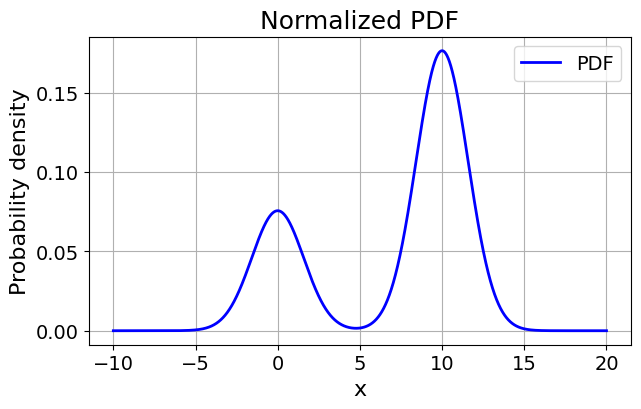

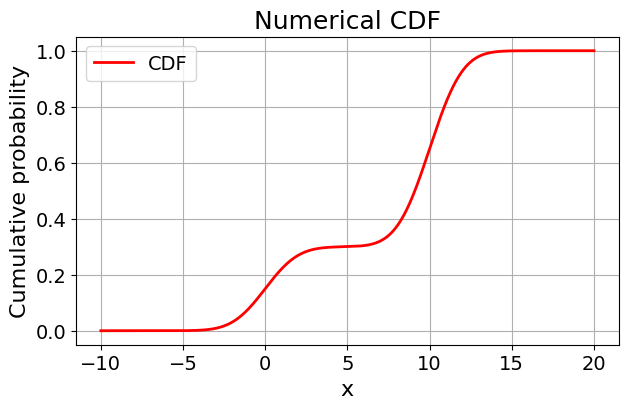

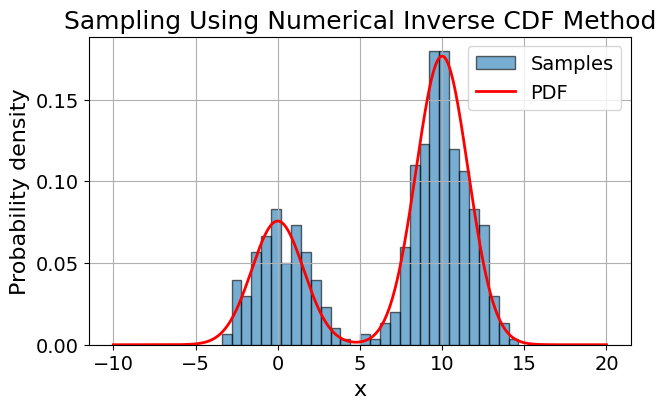

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --------------------------------------------------
# 1. Define unnormalized PDF
# --------------------------------------------------
def unnormalized_pdf(x):
    return 0.3 * np.exp(-0.2 * x**2) + 0.7 * np.exp(-0.2 * (x - 10)**2)

# --------------------------------------------------
# 2. Numerical grid
# --------------------------------------------------
x = np.linspace(-10, 20, 10000)

pdf_unnorm = unnormalized_pdf(x)

# Normalize PDF
area = np.trapezoid(pdf_unnorm, x)
pdf = pdf_unnorm / area

# --------------------------------------------------
# 3. Compute numerical CDF
# --------------------------------------------------
dx = x[1] - x[0]
cdf = np.cumsum(pdf) * dx

# Normalize CDF to make the final value exactly 1
cdf = cdf / cdf[-1]

# --------------------------------------------------
# Plot normalized PDF and numerical CDF
# --------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(x, pdf, 'b', linewidth=2, label='PDF')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title('Normalized PDF')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x, cdf, 'r', linewidth=2, label='CDF')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('Cumulative probability')
plt.title('Numerical CDF')
plt.legend()
plt.show()

# --------------------------------------------------
# 4. Construct inverse CDF
# --------------------------------------------------
inverse_cdf = interp1d(
    cdf,
    x,
    bounds_error=False,
    fill_value=(x[0], x[-1])
)

# --------------------------------------------------
# 5. Generate samples using inverse CDF method
# --------------------------------------------------
ns = 500

np.random.seed(0)
u = np.random.rand(ns)

samples = inverse_cdf(u)

# --------------------------------------------------
# 6. Plot histogram and PDF
# --------------------------------------------------
plt.figure(figsize=(7, 4))

plt.hist(samples, bins=30, density=True, alpha=0.6,
         edgecolor='black', label='Samples')

plt.plot(x, pdf, 'r', linewidth=2, label='PDF')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title('Sampling Using Numerical Inverse CDF Method')
plt.legend()
plt.show()

## Important sampling

### PDF via samples

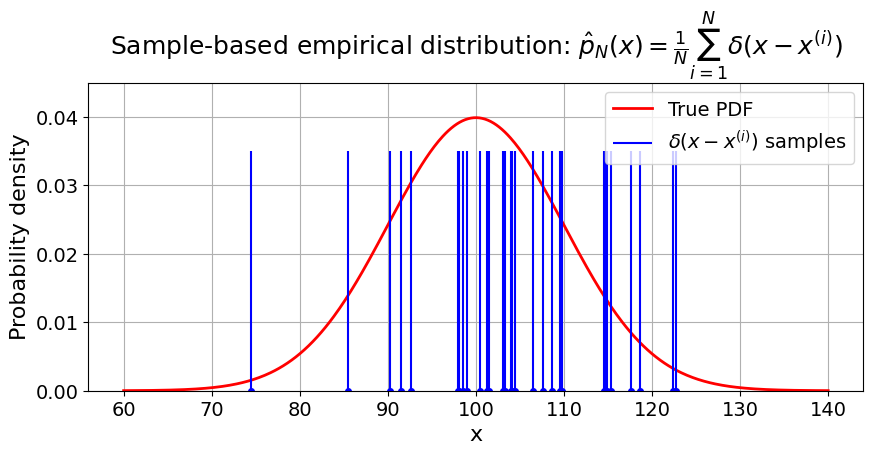

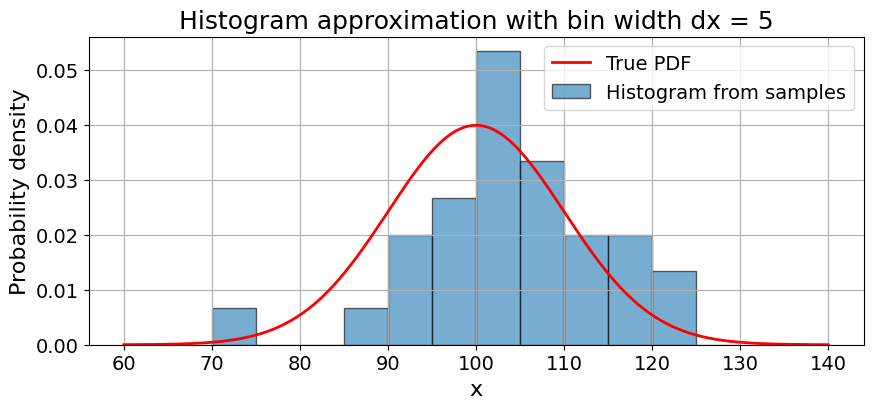

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --------------------------------------------------
# 1. Parameters
# --------------------------------------------------
mu = 100
sigma = 10
N = 30
dx = 5

np.random.seed(0)
x = np.random.normal(mu, sigma, N)

# True PDF
xg = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf = norm.pdf(xg, loc=mu, scale=sigma)

# --------------------------------------------------
# 2. Delta-function representation of samples
# --------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(xg, pdf, 'r', linewidth=2, label='True PDF')

# Visual height for delta spikes
# 실제 delta는 무한대 spike이지만, 그림에서는 보기 위해 일정 높이로 표시
spike_height = 0.035

plt.vlines(
    x,
    ymin=0,
    ymax=spike_height,
    colors='b',
    linewidth=1.5,
    label=r'$\delta(x-x^{(i)})$ samples'
)

plt.plot(x, np.zeros_like(x), 'bo', markersize=4)

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title(
    r'Sample-based empirical distribution: '
    r'$\hat{p}_N(x)=\frac{1}{N}\sum_{i=1}^{N}\delta(x-x^{(i)})$'
)
plt.legend()
plt.ylim(0, 0.045)
plt.show()

# --------------------------------------------------
# 3. Histogram by binning delta samples
# --------------------------------------------------

xmin = np.floor((x.min() - dx) / dx) * dx
xmax = np.ceil((x.max() + dx) / dx) * dx
bins = np.arange(xmin, xmax + dx, dx)

counts, edges = np.histogram(x, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

# Density approximation
hist_density = counts / (N * dx)

plt.figure(figsize=(10, 4))

plt.bar(
    centers,
    hist_density,
    width=dx,
    edgecolor='black',
    alpha=0.6,
    label='Histogram from samples'
)

plt.plot(xg, pdf, 'r', linewidth=2, label='True PDF')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title(f'Histogram approximation with bin width dx = {dx}')
plt.legend()
plt.show()

### Weighted samples of user-defined PDF

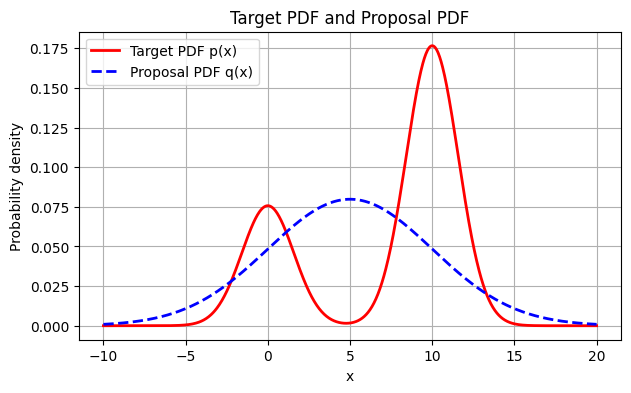

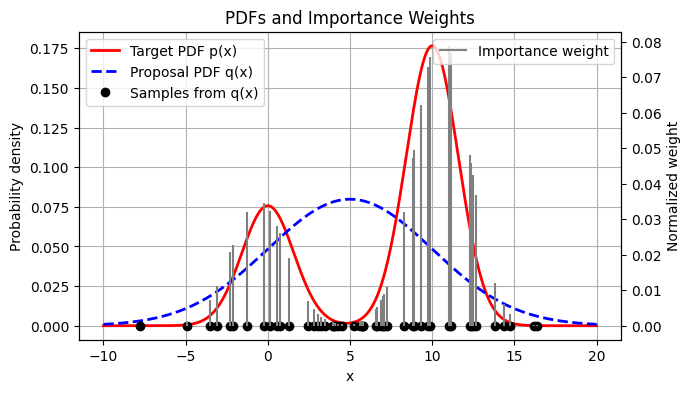

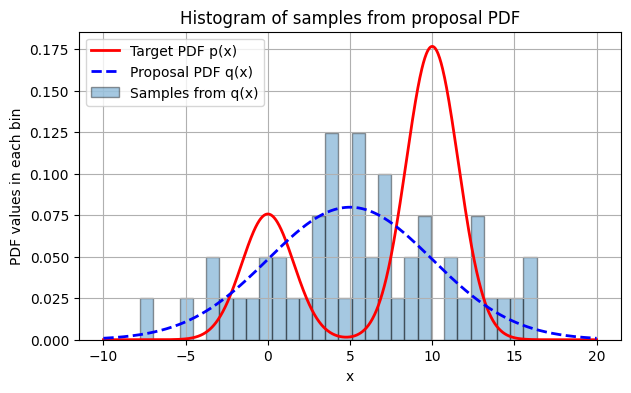

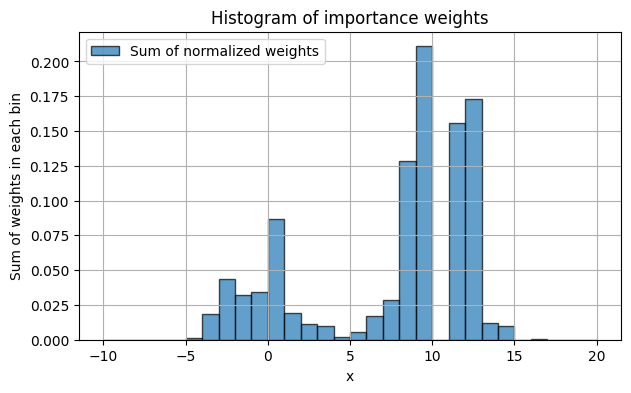

Number of samples = 50

mean = 7.625220
variance = 24.825145
skewness = -0.902767


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --------------------------------------------------
# 1. Define target PDF and proposal PDF
# --------------------------------------------------

# target_pdf_unnorm() and proposal_pdf() are defined once, in the
# Settings and Utilities cell. Only their parameters are set here.
mu_q = 5.0
sigma_q = 5.0

# --------------------------------------------------
# 2. Plot target PDF and proposal PDF first
# --------------------------------------------------

x_grid = np.linspace(-10, 20, 1000)

# Normalize target PDF for plotting
p_grid_unnorm = target_pdf_unnorm(x_grid)
area = np.trapezoid(p_grid_unnorm, x_grid)
p_grid = p_grid_unnorm / area

q_grid = proposal_pdf(x_grid)

plt.figure(figsize=(7, 4))
plt.plot(x_grid, p_grid, 'r', linewidth=2, label='Target PDF p(x)')
plt.plot(x_grid, q_grid, 'b--', linewidth=2, label='Proposal PDF q(x)')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title('Target PDF and Proposal PDF')
plt.legend()
plt.show()

# --------------------------------------------------
# 3. Generate samples from proposal PDF
# --------------------------------------------------

N = 50

np.random.seed(0)
x = np.random.normal(mu_q, sigma_q, N)

# --------------------------------------------------
# 4. Importance weights
# --------------------------------------------------

p_val = target_pdf_unnorm(x)     # unnormalized target PDF is enough
q_val = proposal_pdf(x)

eps = 1e-12
w = p_val / (q_val + eps)

# Normalized weights
w_tilde = w / np.sum(w)

# Sort samples for CDF plotting
idx = np.argsort(x)

x_sorted = x[idx]
w_tilde_sorted = w_tilde[idx]

# --------------------------------------------------
# 5. plot Target PDF, proposal PDF, and importance-weighted proposal samples
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(x_grid, p_grid, 'r', linewidth=2, label='Target PDF p(x)')
ax1.plot(x_grid, q_grid, 'b--', linewidth=2, label='Proposal PDF q(x)')
ax1.plot(x_sorted, np.zeros_like(x_sorted), 'o', color='k', label='Samples from q(x)')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability density')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.vlines(x_sorted, 0, w_tilde_sorted, color='gray', linewidth=1.5, label='Importance weight')
ax2.set_ylabel('Normalized weight')

ax1.set_title('PDFs and Importance Weights')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# --------------------------------------------------
# 6. plot histogram of proposal samples
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(x_grid, p_grid, 'r', linewidth=2, label='Target PDF p(x)')
plt.plot(x_grid, q_grid, 'b--', linewidth=2, label='Proposal PDF q(x)')
plt.hist(x, bins=30, density=True, alpha=0.4,
         edgecolor='black', label='Samples from q(x)')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('PDF values in each bin')
plt.title('Histogram of samples from proposal PDF')
plt.legend()
plt.show()

# --------------------------------------------------
# 7. plot histogram of importance weights
# --------------------------------------------------

# Define bins along x
bins = np.linspace(-10, 20, 31)   # 30 bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Sum of normalized weights in each bin
weight_sum, _ = np.histogram(x, bins=bins, weights=w_tilde)

# Number of samples in each bin, for reference
count_sum, _ = np.histogram(x, bins=bins)

plt.figure(figsize=(7, 4))

plt.bar(bin_centers, weight_sum, width=bin_width,
        alpha=0.7, edgecolor='black', label='Sum of normalized weights')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Sum of weights in each bin')
plt.title('Histogram of importance weights')
plt.legend()
plt.show()

# --------------------------------------------------
# 8. Moments calculation: Mean, variance, skewness by importance sampling
# --------------------------------------------------

# Weighted mean
mu_is = np.sum(w_tilde * x)

# Weighted variance
var_is = np.sum(w_tilde * (x - mu_is)**2)

# Weighted standard deviation
std_is = np.sqrt(var_is)

# Weighted skewness
skew_is = np.sum(w_tilde * ((x - mu_is) / std_is)**3)

print(f"Number of samples = {N}")
print()
print(f"mean = {mu_is:.6f}")
print(f"variance = {var_is:.6f}")
print(f"skewness = {skew_is:.6f}")

### Resampling

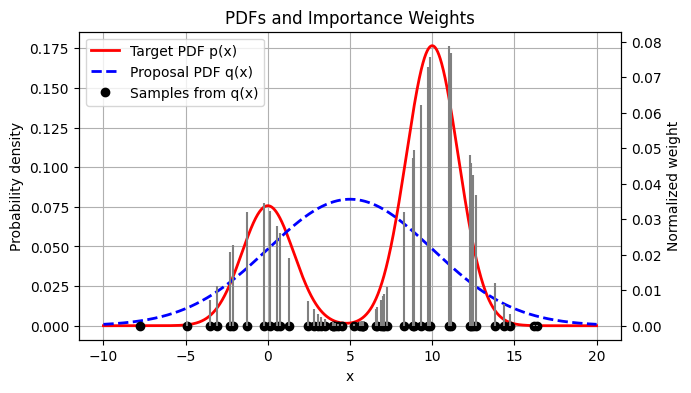

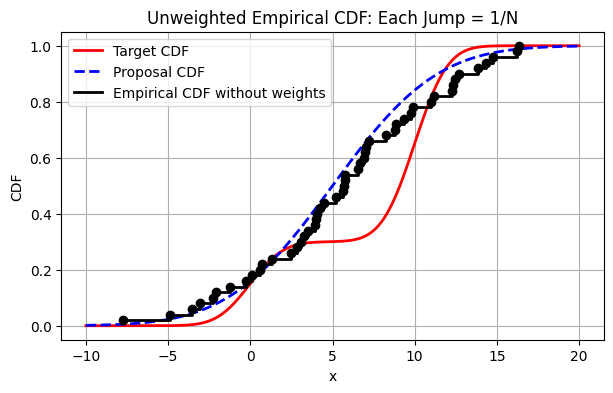

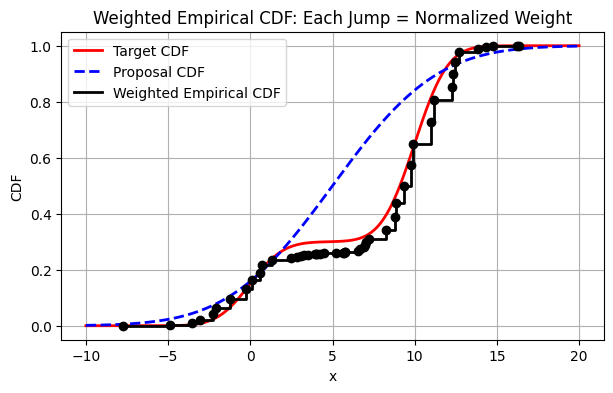

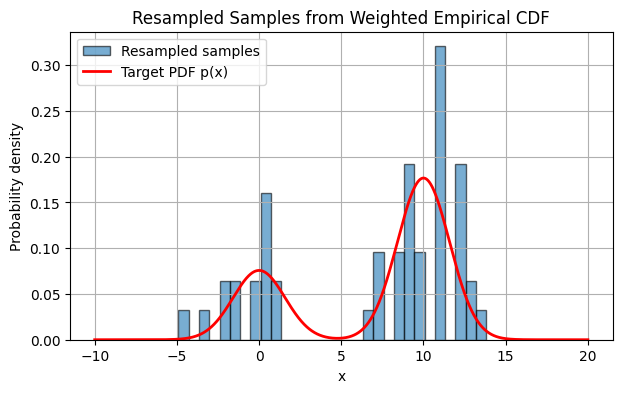

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --------------------------------------------------
# 1. Define target PDF and proposal PDF
# --------------------------------------------------

# target_pdf_unnorm() and proposal_pdf() are defined once, in the
# Settings and Utilities cell. Only their parameters are set here.
mu_q = 5.0
sigma_q = 5.0

def proposal_cdf(x):
    return norm.cdf(x, loc=mu_q, scale=sigma_q)

# --------------------------------------------------
# 2. Normalize target PDF and compute target CDF
# --------------------------------------------------

x_grid = np.linspace(-10, 20, 2000)

p_unnorm_grid = target_pdf_unnorm(x_grid)
area = np.trapezoid(p_unnorm_grid, x_grid)
p_grid = p_unnorm_grid / area

dx = x_grid[1] - x_grid[0]
target_cdf_grid = np.cumsum(p_grid) * dx
target_cdf_grid = target_cdf_grid / target_cdf_grid[-1]

q_grid = proposal_pdf(x_grid)
q_cdf_grid = proposal_cdf(x_grid)

# --------------------------------------------------
# 3. Generate proposal samples
# --------------------------------------------------

N = 50

np.random.seed(0)
x = np.random.normal(mu_q, sigma_q, N)

# --------------------------------------------------
# 4. Importance weights
# --------------------------------------------------

p_val = target_pdf_unnorm(x)
q_val = proposal_pdf(x)

eps = 1e-12
w = p_val / (q_val + eps)
w_tilde = w / np.sum(w)

# Sort samples for CDF plotting
idx = np.argsort(x)

x_sorted = x[idx]
w_tilde_sorted = w_tilde[idx]

cdf_unweighted = np.arange(1, N + 1) / N
cdf_weighted = np.cumsum(w_tilde_sorted)

# --------------------------------------------------
# 5. plot Target PDF, proposal PDF, and weighted samples
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(x_grid, p_grid, 'r', linewidth=2, label='Target PDF p(x)')
ax1.plot(x_grid, q_grid, 'b--', linewidth=2, label='Proposal PDF q(x)')
ax1.plot(x_sorted, np.zeros_like(x_sorted), 'o', color='k', label='Samples from q(x)')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability density')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.vlines(x_sorted, 0, w_tilde_sorted, color='gray', linewidth=1.5)
ax2.set_ylabel('Normalized weight')

ax1.set_title('PDFs and Importance Weights')
ax1.legend(loc='upper left')
plt.show()

# --------------------------------------------------
# 6. plot Unweighted empirical CDF (wrong plot)
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(x_grid, target_cdf_grid, 'r', linewidth=2, label='Target CDF')
plt.plot(x_grid, q_cdf_grid, 'b--', linewidth=2, label='Proposal CDF')

plt.step(x_sorted, cdf_unweighted, where='post',
         color='k', linewidth=2, label='Empirical CDF without weights')

plt.plot(x_sorted, cdf_unweighted, 'ko')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('CDF')
plt.title('Unweighted Empirical CDF: Each Jump = 1/N')
plt.legend(loc='best')
plt.show()

# --------------------------------------------------
# 7. plot weighted empirical CDF (correct)
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(x_grid, target_cdf_grid, 'r', linewidth=2, label='Target CDF')
plt.plot(x_grid, q_cdf_grid, 'b--', linewidth=2, label='Proposal CDF')

plt.step(x_sorted, cdf_weighted, where='post',
         color='k', linewidth=2, label='Weighted Empirical CDF')

plt.plot(x_sorted, cdf_weighted, 'ko')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('CDF')
plt.title('Weighted Empirical CDF: Each Jump = Normalized Weight')
plt.legend(loc='best')
plt.show()

# --------------------------------------------------
# 8. Resampling using inverse CDF of weighted empirical CDF
# --------------------------------------------------

M = N   # number of resampled ordinary samples

# Weighted empirical CDF
weighted_cdf = np.cumsum(w_tilde_sorted)
weighted_cdf = weighted_cdf / weighted_cdf[-1]

# Uniform random numbers
np.random.seed(1)
u = np.random.rand(M)

# Inverse CDF sampling from weighted empirical CDF
resample_idx = np.searchsorted(weighted_cdf, u)

# Final resampled samples
x_resampled = x_sorted[resample_idx]

# --------------------------------------------------
# 9. Plot histogram of resampled samples with target PDF
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.hist(x_resampled, bins=30, density=True, alpha=0.6,
         edgecolor='black', label='Resampled samples')

plt.plot(x_grid, p_grid, 'r', linewidth=2, label='Target PDF p(x)')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title('Resampled Samples from Weighted Empirical CDF')
plt.legend()
plt.show()

## Prognosis by PF for linear/nonlinear problem

### Common particle filter

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


def run_state_particle_filter(
        obs_time, obs_hi, transition, forecast, eol_function,
        init_bounds, state_bounds, measurement_std, future_end,
        n_particles=5000, n_frames=20, interval=(2.5, 97.5),
        seed=2, save_from=0, rw_fraction=0.01,
        initial_particles=None, rw_std=None, likelihood_floor=0.0,
        save_times=None, refresh_state=None, random_generator=None,
        forecast_samples=1000):

    rng = (np.random.default_rng(seed) if random_generator is None
           else random_generator)
    obs_time, obs_hi = np.asarray(obs_time), np.asarray(obs_hi)

    # Each row is [lower, upper] for one state variable.
    init_bounds = np.asarray(init_bounds, dtype=float)
    state_bounds = np.asarray(state_bounds, dtype=float)
    init_low, init_up = init_bounds[:, 0], init_bounds[:, 1]
    state_low, state_up = state_bounds[:, 0], state_bounds[:, 1]

    # Initial particles: [health state, model parameters].
    if initial_particles is None:
        particles = rng.uniform(
            init_low, init_up, (n_particles, len(init_low)))
    else:
        particles = np.asarray(initial_particles, dtype=float).copy()
        if particles.shape != (n_particles, len(init_low)):
            raise ValueError('initial_particles has an invalid shape')
        particles = np.clip(particles, state_low, state_up)
    weights = np.full(n_particles, 1 / n_particles)

    # No random walk for HI unless rw_std is explicitly supplied.
    if rw_std is None:
        fraction = np.broadcast_to(rw_fraction, len(init_low) - 1)
        rw_std = np.zeros(len(init_low))
        rw_std[1:] = fraction * (init_up[1:] - init_low[1:])
    else:
        rw_std = np.broadcast_to(rw_std, len(init_low)).astype(float)

    if save_times is None:
        n_save = min(n_frames, len(obs_time) - save_from)
        save_idx = set(np.unique(np.linspace(
            save_from, len(obs_time) - 1, n_save).astype(int)))
    else:
        save_idx = set(np.unique(np.searchsorted(
            obs_time, np.asarray(save_times), side='left')))
        save_idx = {i for i in save_idx if save_from <= i < len(obs_time)}
    results = []

    for j, (current, measurement) in enumerate(zip(obs_time, obs_hi)):
        # Prediction using the recursive degradation model.
        if j:
            particles = transition(
                particles, obs_time[j - 1], current)
            for state_index in np.flatnonzero(rw_std):
                particles[:, state_index] += rng.normal(
                    0, rw_std[state_index], n_particles)
            particles = np.clip(particles, state_low, state_up)
            if refresh_state is not None:
                particles = refresh_state(particles, current)

        # Correction using the measured health index.
        error = measurement - particles[:, 0]
        likelihood = np.exp(-0.5 * (error / measurement_std)**2)
        likelihood = (1 - likelihood_floor) * likelihood + likelihood_floor
        weights *= likelihood
        weights += np.finfo(float).tiny
        weights /= weights.sum()

        # Resampling when the effective particle number is small.
        if 1 / np.sum(weights**2) < n_particles / 2:
            ids = rng.choice(n_particles, n_particles, p=weights)
            particles = particles[ids]
            weights.fill(1 / n_particles)

        if j not in save_idx:
            continue

        # Forecast each sampled state to the failure threshold.
        ids = rng.choice(
            n_particles, min(forecast_samples, n_particles), p=weights)
        sample = particles[ids]
        eol = eol_function(sample, current)
        valid = np.isfinite(eol) & (eol > current)
        if np.sum(valid) < 20:
            continue

        sample, eol = sample[valid], eol[valid]
        rul = eol - current
        q_low, q_high = interval
        rul_low, rul_med, rul_up = np.percentile(
            rul, [q_low, 50, q_high])
        grid_end = max(future_end, np.percentile(eol, q_high))
        future_time = np.linspace(current, grid_end, 1000)
        prediction = forecast(
            future_time[:, None], current, sample[None, :, :])
        hi_low, hi_med, hi_up = np.percentile(
            prediction, [q_low, 50, q_high], axis=1)

        results.append({
            'time': current, 'states': sample,
            'state_median': np.median(sample, axis=0),
            'future_time': future_time, 'hi_median': hi_med,
            'hi_low': hi_low, 'hi_up': hi_up,
            'eol': current + rul_med, 'rul': rul_med,
            'rul_low': rul_low, 'rul_up': rul_up})

    return results


def plot_pf_results(
        results, time, hi, threshold, true_eol,
        title, show_time, xlim, ylim, animate=False):

    show = min(range(len(results)),
               key=lambda i: abs(results[i]['time'] - show_time))
    frames = range(len(results)) if animate else [show]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.subplots_adjust(
        left=0.07, right=0.98, bottom=0.14, top=0.90, wspace=0.16)

    def draw(i):
        for ax in axes:
            ax.clear()
        r = results[i]
        current = r['time']
        used = time <= current
        history = results[:i + 1] if animate else results
        pt = np.array([x['time'] for x in history])

        axes[0].plot(time[used], hi[used], 'ko', label='Data used')
        axes[0].plot(time[~used], hi[~used], 'mo', label='Data future')
        axes[0].plot(r['future_time'], r['hi_median'], '--b',
                     label='PF prediction')
        axes[0].fill_between(
            r['future_time'], r['hi_low'], r['hi_up'],
            color='tab:blue', alpha=0.18, label='95% interval')
        axes[0].axhline(threshold, color='r', label='Threshold')
        axes[0].axvline(current, color='gray', linestyle=':')
        axes[0].set(xlim=xlim, ylim=ylim, xlabel='Time',
                    ylabel='Health index',
                    title=f'{title} at t = {current:g}')
        axes[0].grid(True); axes[0].legend()

        axes[1].plot(time, true_eol - time, 'k', label='True RUL')
        axes[1].plot(pt, [x['rul'] for x in history],
                     'bo-', label='Predicted RUL')
        axes[1].plot(pt, [x['rul_low'] for x in history],
                     'g--', label='95% interval')
        axes[1].plot(pt, [x['rul_up'] for x in history], 'g--')
        axes[1].axvline(current, color='gray', linestyle=':')
        axes[1].set(xlim=xlim, ylim=(0, 1.1 * np.max(true_eol - time)),
                    xlabel='Time', ylabel='RUL',
                    title='RUL Prediction by PF')
        axes[1].grid(True); axes[1].legend()

    if animate:
        anim = FuncAnimation(
            fig, draw, frames=frames, interval=1000, repeat=False)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))
    else:
        draw(show)
        plt.show()


### Linear problem

In [ ]:
# Linear problem
pf_y = np.array([
    -0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.605, 0.608,
     0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586])
pf_t = np.arange(len(pf_y))
pf_threshold = 1.2


def linear_transition(p, t_old, t_new):
    # y_k = y_(k-1) + b * dt; b is constant before random walk.
    q = p.copy()
    q[:, 0] = p[:, 0] + p[:, 1] * (t_new - t_old)
    return q


def linear_forecast(t, current, p):
    # Future HI from each current state particle.
    return p[..., 0] + p[..., 1] * (t - current)


def linear_eol(p, current):
    # Threshold-crossing time of each particle.
    return current + (pf_threshold - p[:, 0]) / p[:, 1]


# Estimate measurement noise from the full-regression residuals.
pf_full = np.polyfit(pf_t, pf_y, 1)
pf_resid = pf_y - np.polyval(pf_full, pf_t)
pf_measurement_std = np.sqrt(
    np.sum(pf_resid**2) / (len(pf_y) - 2))
pf_true_eol = (pf_threshold - pf_full[1]) / pf_full[0]

# Initial HI uses the first measurement +/- 3 sigma.
hi0_bounds = [pf_y[0] - 3 * pf_measurement_std,
              pf_y[0] + 3 * pf_measurement_std]
b_bounds = [0.03, 0.20]  # Prior range of the positive degradation rate

linear_pf = run_state_particle_filter(
    pf_t, pf_y, linear_transition, linear_forecast, linear_eol,
    init_bounds=[hi0_bounds, b_bounds],
    state_bounds=[[-1.0, 2.0], [1e-4, 1.0]],
    measurement_std=pf_measurement_std,
    future_end=20, save_from=2)

plot_pf_results(
    linear_pf, pf_t, pf_y, pf_threshold, pf_true_eol,
    'PF prediction for linear problem', show_time=5,
    xlim=(0, 13), ylim=(-0.1, 1.5))

plot_pf_results(
    linear_pf, pf_t, pf_y, pf_threshold, pf_true_eol,
    'PF prediction for linear problem', show_time=5,
    xlim=(0, 13), ylim=(-0.1, 1.5), animate=True)


### Nonlinear problem

In [ ]:
# Nonlinear problem
pf_yy = np.array([
    6.99, 2.28, 1.91, 11.94, 14.60, 22.30,
    37.85, 50.20, 70.18, 97.69, 128.05])
pf_tt = np.arange(len(pf_yy))
pf_thres = 120


def nonlinear_transition(p, t_old, t_new):
    # Recursive form of y = 5 + b1*t^2 + b2*t^3.
    q = p.copy()
    q[:, 0] = p[:, 0] + p[:, 1] * (t_new**2 - t_old**2)
    q[:, 0] += p[:, 2] * (t_new**3 - t_old**3)
    return q


def nonlinear_forecast(t, current, p):
    # Future HI from each current state particle.
    y = p[..., 0] + p[..., 1] * (t**2 - current**2)
    return y + p[..., 2] * (t**3 - current**3)


def nonlinear_eol(p, current):
    # Positive threshold-crossing root of each particle.
    eol = np.full(len(p), np.nan)
    c0 = p[:, 0] - p[:, 1] * current**2
    c0 -= p[:, 2] * current**3 + pf_thres
    for i, (y0, b1, b2) in enumerate(zip(c0, p[:, 1], p[:, 2])):
        roots = np.roots([b2, b1, 0, y0])
        roots = roots[np.isreal(roots)].real
        roots = roots[roots > current]
        if len(roots):
            eol[i] = np.min(roots)
    return eol


# Estimate parameters and measurement noise from full-regression residuals.
F_full = np.column_stack((pf_tt**2, pf_tt**3))
pf_beta_full = np.linalg.lstsq(
    F_full, pf_yy - 5, rcond=None)[0]
pf_resid = pf_yy - (5 + F_full @ pf_beta_full)
pf_measurement_std = np.sqrt(
    np.sum(pf_resid**2) / (len(pf_yy) - 2))
pf_true_eol = nonlinear_eol(
    np.array([[5, *pf_beta_full]]), 0)[0]

# Initial HI uses the first measurement +/- 3 sigma.
hi0_bounds = [pf_yy[0] - 3 * pf_measurement_std,
              pf_yy[0] + 3 * pf_measurement_std]
b1_bounds = [-1.0, 1.0]  # Prior coefficient ranges
b2_bounds = [0.02, 0.20]

nonlinear_pf = run_state_particle_filter(
    pf_tt, pf_yy, nonlinear_transition,
    nonlinear_forecast, nonlinear_eol,
    init_bounds=[hi0_bounds, b1_bounds, b2_bounds],
    state_bounds=[[-20, 200], [-10, 10], [1e-6, 10]],
    measurement_std=pf_measurement_std,
    future_end=14, save_from=2)

plot_pf_results(
    nonlinear_pf, pf_tt, pf_yy, pf_thres, pf_true_eol,
    'PF prediction for nonlinear problem', show_time=4,
    xlim=(0, 11), ylim=(0, 140))

plot_pf_results(
    nonlinear_pf, pf_tt, pf_yy, pf_thres, pf_true_eol,
    'PF prediction for nonlinear problem', show_time=7,
    xlim=(0, 11), ylim=(0, 140), animate=True)


### Exponential degradation under a state change

#### Simulation data

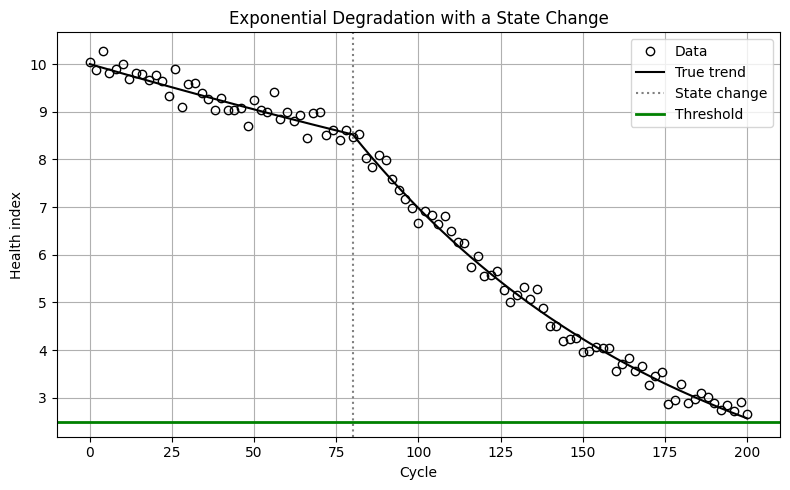

True EOL = 202.6


In [ ]:
# State-change simulation based on Kim et al. (2021)
sc_t = np.arange(0, 201)
sc_change = 80
sc_prediction_cycle = 120
sc_x0 = 10.0
sc_b_before = 0.002
sc_b_after = 0.010
sc_noise_std = 0.2 # original 0.1
sc_threshold = 2.5
sc_rng = np.random.default_rng(2)

# Recursive exponential degradation with a parameter change.
sc_true = np.where(
    sc_t <= sc_change,
    sc_x0 * np.exp(-sc_b_before * sc_t),
    sc_x0 * np.exp(-sc_b_before * sc_change)
    * np.exp(-sc_b_after * (sc_t - sc_change)))
sc_y = sc_true + sc_rng.normal(0, sc_noise_std, len(sc_t))
sc_true_eol = (sc_change
    + np.log(sc_true[sc_change] / sc_threshold) / sc_b_after)

plt.figure(figsize=(8, 5))
plt.plot(sc_t[::2], sc_y[::2], 'ko', markerfacecolor='none', label='Data')
plt.plot(sc_t, sc_true, 'k-', label='True trend')
plt.axvline(sc_change, color='gray', linestyle=':', label='State change')
plt.axhline(sc_threshold, color='g', linewidth=2, label='Threshold')
plt.xlabel('Cycle'); plt.ylabel('Health index')
plt.title('Exponential Degradation with a State Change')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print(f'True EOL = {sc_true_eol:.1f}')


#### Probabilistic prognosis using nonlinear regression

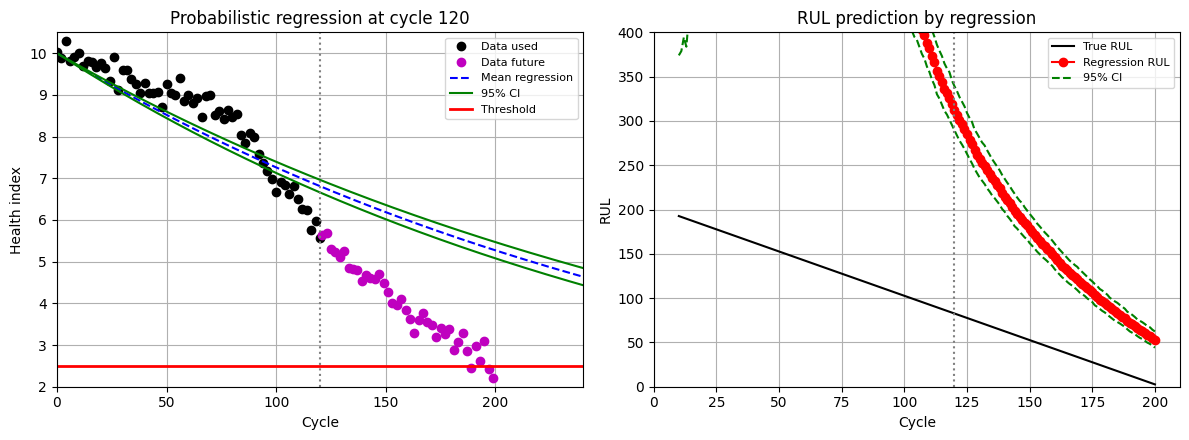

Regression b at cycle 120 = 0.00320
Regression RUL at cycle 120 = 312.9


In [ ]:
# Sequential probabilistic regression using all available data
sc_regression = []
sc_log_threshold = np.log(sc_x0 / sc_threshold)

# Continue the sequential prediction through the entire test record.
for k in range(10, len(sc_t)):
    t_used = sc_t[:k + 1]
    y_used = np.maximum(sc_y[:k + 1], 1e-6)
    log_y = np.log(y_used / sc_x0)

    # Single exponential model: x = x0*exp(-b*t)
    b_hat = -np.linalg.lstsq(
        t_used[:, None], log_y, rcond=None)[0][0]
    residual = log_y + b_hat * t_used
    b_std = np.sqrt(
        np.sum(residual**2) / (len(t_used) - 1)
        / np.sum(t_used**2))

    b_sample = sc_rng.normal(b_hat, b_std, 5000)
    b_sample = b_sample[b_sample > 0]
    eol_sample = sc_log_threshold / b_sample
    rul_sample = eol_sample - t_used[-1]
    rul_sample = rul_sample[rul_sample > 0]

    sc_regression.append({
        'time': t_used[-1], 'b': b_hat, 'b_std': b_std,
        'eol': sc_log_threshold / b_hat,
        'rul': np.median(rul_sample),
        'rul_low': np.percentile(rul_sample, 2.5),
        'rul_up': np.percentile(rul_sample, 97.5)})

sc_reg_show = min(
    sc_regression,
    key=lambda r: abs(r['time'] - sc_prediction_cycle))
sc_grid = np.linspace(0, 240, 1500)
sc_reg_curve = sc_x0 * np.exp(-sc_reg_show['b'] * sc_grid)

# Confidence interval of the estimated mean degradation curve.
sc_ci_rng = np.random.default_rng(2)
sc_b_sample = sc_ci_rng.normal(
    sc_reg_show['b'], sc_reg_show['b_std'], 5000)
sc_b_sample = sc_b_sample[sc_b_sample > 0]
sc_curve_sample = sc_x0 * np.exp(
    -sc_grid[:, None] * sc_b_sample[None, :])
sc_curve_low, sc_curve_up = np.percentile(
    sc_curve_sample, [2.5, 97.5], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
used = sc_t <= sc_prediction_cycle
used_idx = np.flatnonzero(used)[::2]
future_idx = np.flatnonzero(~used)[::2]
axes[0].plot(sc_t[used_idx], sc_y[used_idx], 'ko', label='Data used')
axes[0].plot(sc_t[future_idx], sc_y[future_idx], 'mo',
             label='Data future')
axes[0].plot(sc_grid, sc_reg_curve, '--b', label='Mean regression')
axes[0].plot(sc_grid, sc_curve_low, 'g-', label='95% CI')
axes[0].plot(sc_grid, sc_curve_up, 'g-')
axes[0].axhline(sc_threshold, color='r', linewidth=2, label='Threshold')
axes[0].axvline(sc_prediction_cycle, color='gray', linestyle=':')
axes[0].set(xlim=(0, 240), ylim=(2, 10.5), xlabel='Cycle',
            ylabel='Health index',
            title=f'Probabilistic regression at cycle {sc_prediction_cycle}')
axes[0].grid(True); axes[0].legend(fontsize=8)

reg_time = np.array([r['time'] for r in sc_regression])
reg_rul = np.array([r['rul'] for r in sc_regression])
reg_low = np.array([r['rul_low'] for r in sc_regression])
reg_up = np.array([r['rul_up'] for r in sc_regression])
axes[1].plot(reg_time, sc_true_eol - reg_time, 'k-', label='True RUL')
axes[1].plot(reg_time, reg_rul, 'ro-', label='Regression RUL')
axes[1].plot(reg_time, reg_low, 'g--', label='95% CI')
axes[1].plot(reg_time, reg_up, 'g--')
axes[1].axvline(sc_prediction_cycle, color='gray', linestyle=':')
axes[1].set(xlim=(0, 210), ylim=(0, 400), xlabel='Cycle', ylabel='RUL',
            title='RUL prediction by regression')
axes[1].grid(True); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'Regression b at cycle 120 = {sc_reg_show["b"]:.5f}')
print(f'Regression RUL at cycle 120 = {sc_reg_show["rul"]:.1f}')


#### Prognosis using the common particle filter

In [ ]:
# Common PF with random walk of degradation parameter b
def sc_transition(p, t_old, t_new):
    q = p.copy()
    q[:, 0] = p[:, 0] * np.exp(-p[:, 1] * (t_new - t_old))
    return q


def sc_forecast(t, current, p):
    return p[..., 0] * np.exp(-p[..., 1] * (t - current))


def sc_eol(p, current):
    return current + np.log(p[:, 0] / sc_threshold) / p[:, 1]


# Assimilate the complete test record so that the RUL curve reaches the end.
sc_pf = run_state_particle_filter(
    sc_t, sc_y,
    sc_transition, sc_forecast, sc_eol,
    init_bounds=[[sc_y[0] - 0.3, sc_y[0] + 0.3],
                 [0.0005, 0.004]],
    state_bounds=[[0.1, 12.0], [1e-6, 0.03]],
    measurement_std=sc_noise_std, future_end=240,
    n_particles=5000, interval=(2.5, 97.5),
    save_times=np.arange(10, len(sc_t), 10),
    rw_std=[0, 0.0004], seed=2)

# State-change PF plot. The common plotting utility is left unchanged.
sc_pf_show = min(
    sc_pf, key=lambda r: abs(r['time'] - sc_prediction_cycle))
sc_used = sc_t <= sc_prediction_cycle
sc_used_idx = np.flatnonzero(sc_used)[::2]
sc_future_idx = np.flatnonzero(~sc_used)[::2]
pf_time = np.array([r['time'] for r in sc_pf])
pf_rul = np.array([r['rul'] for r in sc_pf])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sc_t[sc_used_idx], sc_y[sc_used_idx],
             'ko', label='Data used')
axes[0].plot(sc_t[sc_future_idx], sc_y[sc_future_idx],
             'mo', label='Data future')
axes[0].plot(sc_pf_show['future_time'], sc_pf_show['hi_median'],
             '--b', label='PF prediction')
axes[0].fill_between(
    sc_pf_show['future_time'], sc_pf_show['hi_low'], sc_pf_show['hi_up'],
    color='tab:blue', alpha=0.18, label='95% interval')
axes[0].axhline(sc_threshold, color='r', linewidth=2, label='Threshold')
axes[0].axvline(sc_prediction_cycle, color='gray', linestyle=':')
axes[0].set(xlim=(0, 240), ylim=(2, 10.5), xlabel='Cycle',
            ylabel='Health index',
            title=f'PF prediction after a state change at cycle '
                  f'{sc_prediction_cycle}')
axes[0].grid(True); axes[0].legend(fontsize=8)

axes[1].plot(sc_t, sc_true_eol - sc_t, 'k-', label='True RUL')
axes[1].plot(pf_time, pf_rul, 'bo-', label='Predicted RUL')
axes[1].plot(pf_time, [r['rul_low'] for r in sc_pf],
             'g--', label='95% interval')
axes[1].plot(pf_time, [r['rul_up'] for r in sc_pf], 'g--')
axes[1].axvline(sc_prediction_cycle, color='gray', linestyle=':')
axes[1].set(xlim=(0, 210), ylim=(0, 400), xlabel='Cycle', ylabel='RUL',
            title='RUL Prediction by PF')
axes[1].grid(True); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Direct comparison of regression and PF.
pf_b = np.array([r['state_median'][1] for r in sc_pf])
reg_b = np.array([r['b'] for r in sc_regression])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(reg_time, sc_true_eol - reg_time, 'k-', label='True RUL')
axes[0].plot(reg_time, reg_rul, 'ro-', label='Regression RUL')
axes[0].plot(pf_time, pf_rul, 'bo-', label='PF RUL')
axes[0].axvline(sc_change, color='gray', linestyle=':',
                label='State change')
axes[0].set(xlim=(0, 210), ylim=(0, 400), xlabel='Cycle', ylabel='RUL',
            title='Regression versus PF')
axes[0].grid(True); axes[0].legend()

axes[1].plot(reg_time, reg_b, 'r-', linewidth=2,
             label='Regression estimate')
axes[1].plot(pf_time, pf_b, 'bo-', label='PF estimate')
axes[1].plot(sc_t,
             np.where(sc_t <= sc_change, sc_b_before, sc_b_after),
             'k--', linewidth=2, label='True b')
axes[1].axvline(sc_change, color='gray', linestyle=':')
axes[1].set(xlim=(0, 210), ylim=(0, 0.015), xlabel='Cycle',
            ylabel='b', title='Degradation-parameter tracking')
axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'True RUL at cycle 120 = {sc_true_eol - 120:.1f}')
print(f'PF RUL at cycle 120 = {sc_pf_show["rul"]:.1f}')
print(f'PF estimate of b at cycle 120 = '
      f'{sc_pf_show["state_median"][1]:.5f}')


## SOH estimation

### Loading Training Cells and Extracting RPT SOH

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path('/content/drive/MyDrive/PHM Practice/Datasets')
data_dir = DATA_ROOT / 'Battery_CMU'
test_cell = 'VAH12'


# Load one cell's CSV, tag cycles, and split into RPT vs. mission cycles.
def prepare_cell(cell):
    path = data_dir / f'{cell}.csv'
    if not path.exists():
        raise FileNotFoundError(path)

    data = pd.read_csv(path)
    data.columns = (
        data.columns.str.strip()
        .str.replace(' ', '_', regex=False))

    local = data['cycleNumber'].astype(int)
    ns = data['Ns'].astype(int)
    new_cycle = (
        local.ne(local.shift())
        | (ns.eq(0) & ns.shift().ne(0)))
    new_cycle.iloc[0] = True
    data['global_cycle'] = new_cycle.cumsum().astype(int)

    summary = data.groupby('global_cycle').agg(
        start_time=('time_s', 'min'),
        end_time=('time_s', 'max'),
        capacity_ah=(
            'QDischarge_mA_h', lambda x: x.max() / 1000))
    summary['duration_h'] = (
        summary['end_time'] - summary['start_time']) / 3600

    presence = pd.crosstab(data['global_cycle'], ns).gt(0)
    has_2 = presence.get(2, pd.Series(False, index=presence.index))
    has_7 = presence.get(7, pd.Series(False, index=presence.index))
    rpt_mask = (
        has_2 & has_7
        & (summary['duration_h'] > 5)
        & (summary['capacity_ah'] > 1.5))

    rpt_cycles = summary.index[rpt_mask].to_numpy()
    mission_cycles = summary.index[~rpt_mask].to_numpy()
    reference = summary.loc[
        rpt_cycles, ['capacity_ah']].reset_index()
    reference['cycle'] = reference['global_cycle'] - 1
    reference['soh'] = (
        reference['capacity_ah']
        / reference['capacity_ah'].iloc[0])

    return {
        'data': data,
        'summary': summary,
        'rpt_cycles': rpt_cycles,
        'mission_cycles': mission_cycles,
        'reference': reference}


cell_records = {test_cell: prepare_cell(test_cell)}
record = cell_records[test_cell]

cell_overview = pd.DataFrame([{
    'cell': test_cell,
    'cycles': record['data']['global_cycle'].nunique(),
    'RPTs': len(record['reference']),
    'initial_capacity': record['reference']['capacity_ah'].iloc[0],
    'final_SOH': record['reference']['soh'].iloc[-1]
}])
display(cell_overview.round(3))

,cell,cycles,RPTs,initial_capacity,final_SOH
0,VAH12,2349,47,3.061,0.735


### charge curve vs SOH

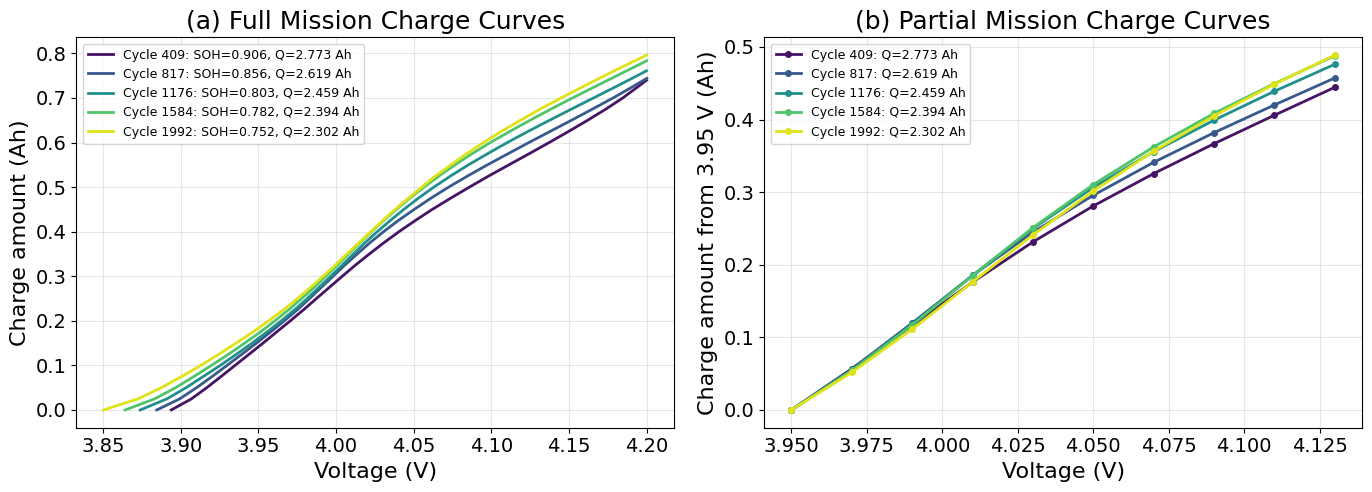

In [ ]:
# Full and partial mission charge curves preceding selected RPTs
data = record['data']
reference = record['reference']
missions = np.asarray(record['mission_cycles'])
voltage_grid = np.arange(3.95, 4.131, 0.02)
target_cycles = [400, 800, 1200, 1600, 2000]
selected = []

for target in target_cycles:
    row = reference.loc[(reference['global_cycle'] - target).abs().idxmin()]
    rpt_cycle = int(row['global_cycle'])

    for mission_cycle in missions[missions < rpt_cycle][::-1]:
        d = data[
            (data['global_cycle'] == mission_cycle)
            & (data['Ns'] == 0)
            & (data['I_mA'] > 100)
        ].copy()

        if len(d) < 10:
            continue

        p = d.sort_values('Ecell_V').drop_duplicates('Ecell_V')

        if (p['Ecell_V'].min() > voltage_grid[0]
                or p['Ecell_V'].max() < voltage_grid[-1]):
            continue

        partial_q = np.interp(
            voltage_grid, p['Ecell_V'],
            p['QCharge_mA_h']
        ) / 1000
        partial_q -= partial_q[0]

        d = d.sort_values('time_s')
        full_q = d['QCharge_mA_h'].to_numpy() / 1000
        full_q -= full_q[0]

        selected.append({
            'cycle': rpt_cycle,
            'soh': float(row['soh']),
            'capacity': float(row['capacity_ah']),
            'full_v': d['Ecell_V'].to_numpy(),
            'full_q': full_q,
            'partial_q': partial_q
        })
        break

if len(selected) != len(target_cycles):
    raise ValueError(f'Only {len(selected)} valid curves were found')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(selected)))

for item, color in zip(selected, colors):
    cycle = item['cycle']
    soh = item['soh']
    capacity = item['capacity']

    axes[0].plot(
        item['full_v'], item['full_q'],
        lw=2, color=color,
        label=f'Cycle {cycle}: SOH={soh:.3f}, Q={capacity:.3f} Ah'
    )
    axes[1].plot(
        voltage_grid, item['partial_q'],
        'o-', ms=4, lw=2, color=color,
        label=f'Cycle {cycle}: Q={capacity:.3f} Ah'
    )

axes[0].set(
    title='(a) Full Mission Charge Curves',
    xlabel='Voltage (V)',
    ylabel='Charge amount (Ah)'
)
axes[1].set(
    title='(b) Partial Mission Charge Curves',
    xlabel='Voltage (V)',
    ylabel='Charge amount from 3.95 V (Ah)'
)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### meta model by polynomial

Training RPT samples   = 24
Validation RPT samples = 23
SOH MAE                = 0.61%
SOH RMSE               = 0.80%


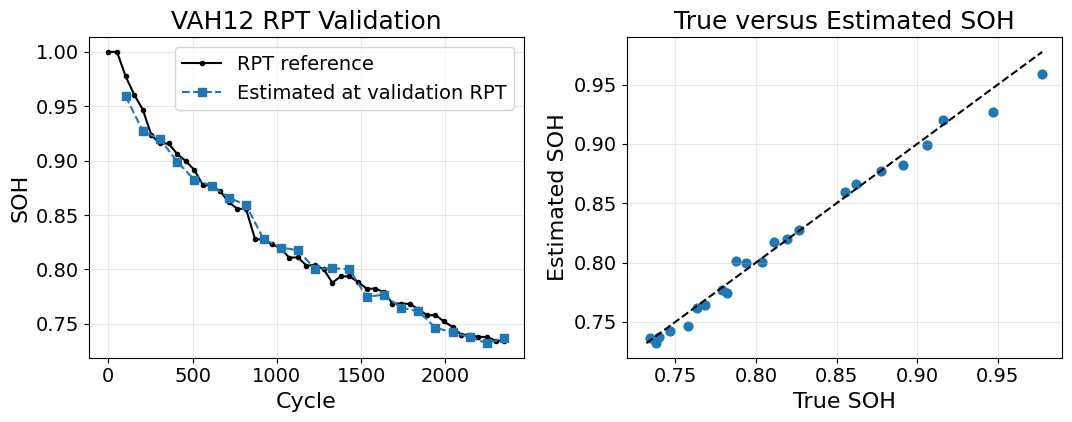

In [ ]:
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_absolute_error, mean_squared_error

voltage_grid = np.arange(3.95, 4.141, 0.02)


# Interpolate the charge-vs-voltage curve of one mission cycle onto voltage_grid.
def extract_charge_amount(data, cycle):
    d = data[
        (data['global_cycle'] == cycle)
        & (data['Ns'] == 0)
        & (data['I_mA'] > 100)
    ].copy()

    if len(d) < 10:
        return None

    d = d.sort_values('Ecell_V').drop_duplicates('Ecell_V')
    if (d['Ecell_V'].min() > voltage_grid[0]
            or d['Ecell_V'].max() < voltage_grid[-1]):
        return None

    q = np.interp(
        voltage_grid, d['Ecell_V'], d['QCharge_mA_h']) / 1000
    return q - q[0]


record = cell_records[test_cell]
missions = np.asarray(record['mission_cycles'])

baseline_curves = []
for cycle in missions:
    curve = extract_charge_amount(record['data'], cycle)
    if curve is not None:
        baseline_curves.append(curve)
    if len(baseline_curves) == 5:
        break

if len(baseline_curves) < 5:
    raise ValueError(
        f'Only {len(baseline_curves)} initial charge curves were found')

baseline = np.mean(baseline_curves, axis=0)
curves, soh, rpt_cycle = [], [], []

# Pair each RPT SOH with the nearest valid preceding mission curve.
for _, row in record['reference'].iloc[1:].iterrows():
    rpt = int(row['global_cycle'])
    previous = missions[missions < rpt]
    curve = None

    for mission in previous[::-1]:
        curve = extract_charge_amount(record['data'], mission)
        if curve is not None:
            break

    if curve is not None:
        curves.append((curve - baseline) / baseline[-1])
        soh.append(row['soh'])
        rpt_cycle.append(rpt)

curves = np.asarray(curves)
soh = np.asarray(soh)
rpt_cycle = np.asarray(rpt_cycle)

if len(soh) < 8:
    raise ValueError(f'Only {len(soh)} RPT charge curves were found')

index = np.arange(len(soh))
train_mask = index % 2 == 0
validation_mask = ~train_mask

train_curves = np.vstack([
    np.zeros(len(voltage_grid)), curves[train_mask]])
train_soh = np.r_[1.0, soh[train_mask]]

coefficients = np.array([
    np.polyfit(train_soh, train_curves[:, k], 3)
    for k in range(len(voltage_grid))])
weights = np.linspace(0.2, 1.0, len(voltage_grid))**2


# SOH whose meta-model charge curve best matches the observed `curve`.
def estimate_soh(curve):
    def objective(value):
        predicted = np.array([
            np.polyval(c, value) for c in coefficients])
        return np.sum(weights * (curve - predicted)**2)

    return minimize_scalar(
        objective, bounds=(0.65, 1.02), method='bounded').x


soh_validation = np.array([
    estimate_soh(curve) for curve in curves[validation_mask]])
soh_reference = soh[validation_mask]
cycle_validation = rpt_cycle[validation_mask]

mae = mean_absolute_error(soh_reference, soh_validation)
rmse = np.sqrt(mean_squared_error(soh_reference, soh_validation))

print(f'Training RPT samples   = {train_mask.sum() + 1}')
print(f'Validation RPT samples = {validation_mask.sum()}')
print(f'SOH MAE                = {100 * mae:.2f}%')
print(f'SOH RMSE               = {100 * rmse:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(
    record['reference']['global_cycle'],
    record['reference']['soh'],
    'k.-', label='RPT reference')
axes[0].plot(
    cycle_validation, soh_validation,
    's--', label='Estimated at validation RPT')
axes[0].set(
    xlabel='Cycle', ylabel='SOH',
    title='VAH12 RPT Validation')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(soh_reference, soh_validation, s=40)
limit = [
    min(soh_reference.min(), soh_validation.min()),
    max(soh_reference.max(), soh_validation.max())]
axes[1].plot(limit, limit, 'k--')
axes[1].set(
    xlabel='True SOH', ylabel='Estimated SOH',
    title='True versus Estimated SOH')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### SOH estimation for all cycles

In [ ]:
mission_soh = []

for cycle in record['mission_cycles']:
    curve = extract_charge_amount(record['data'], int(cycle))
    if curve is not None:
        feature = (curve - baseline) / baseline[-1]
        mission_soh.append([int(cycle), estimate_soh(feature)])

mission_soh = pd.DataFrame(
    mission_soh, columns=['cycle', 'soh_estimated'])

if len(mission_soh) < 20:
    raise ValueError(f'Only {len(mission_soh)} SOH values were found')

mission_soh_10 = mission_soh.copy()
mission_soh_10['cycle'] = mission_soh_10['cycle'] // 10 * 10
mission_soh_10 = mission_soh_10.groupby(
    'cycle', as_index=False).soh_estimated.median()

print(f'Mission SOH estimates = {len(mission_soh)}')
print(f'10-cycle median points = {len(mission_soh_10)}')
print(f'SOH range = {mission_soh_10.soh_estimated.min():.3f}–'
      f'{mission_soh_10.soh_estimated.max():.3f}')

plt.figure(figsize=(10, 5))
plt.scatter(mission_soh_10.cycle, mission_soh_10.soh_estimated,
            s=10, alpha=0.7, label='10-cycle median SOH')
plt.plot(record['reference'].global_cycle, record['reference'].soh,
         'ko-', markersize=4, label='RPT reference')
plt.axhline(0.8, color='red', linestyle='--', label='EOL threshold')
plt.xlabel('Cycle'); plt.ylabel('SOH')
plt.title('VAH12 Mission-by-Mission SOH Estimation')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### RUL prediction using the common particle filter

In [ ]:
from scipy.optimize import curve_fit

rng = np.random.default_rng(2)
eol_threshold = 0.8
selected_cycle = 800
n_particles = 5000
measurement_std = 0.02

pf_observation = mission_soh.copy()
pf_observation['block'] = (pf_observation['cycle'] // 10) * 10
pf_observation = pf_observation.groupby(
    'block', as_index=False)['soh_estimated'].median()
obs_cycle = pf_observation['block'].to_numpy()
obs_soh = pf_observation['soh_estimated'].to_numpy()
ref_cycle = record['reference']['global_cycle'].to_numpy()
ref_soh = record['reference']['soh'].to_numpy()


# Two-parameter exponential SOH decay model: SOH = exp(-a * cycle^b).
def degradation_model(k, a, b):
    return np.exp(-a * k**b)


# Prior from calibration RPT samples
cal_cycle = np.r_[0, rpt_cycle[train_mask]]
cal_soh = np.r_[1.0, soh[train_mask]]
prior, _ = curve_fit(
    degradation_model, cal_cycle, cal_soh, p0=[1e-4, 1.0],
    bounds=([1e-8, 0.1], [0.1, 3.0]), maxfev=20000)
a0, b0 = prior

# Actual EOL from RPT reference
j = np.where(ref_soh <= eol_threshold)[0][0]
c0, c1 = ref_cycle[j - 1], ref_cycle[j]
s0, s1 = ref_soh[j - 1], ref_soh[j]
actual_eol = c0 + (eol_threshold - s0) * (c1 - c0) / (s1 - s0)

# Initial augmented-state particles: [SOH, a, b]
a = a0 * np.exp(rng.normal(0, 0.35, n_particles))
b = b0 * np.exp(rng.normal(0, 0.15, n_particles))
a *= np.exp(rng.normal(0, 0.0005, n_particles))
b *= np.exp(rng.normal(0, 0.0002, n_particles))
initial_particles = np.column_stack([
    degradation_model(obs_cycle[0], a, b), a, b])


# Random walk on (a, b), then recompute SOH at the new cycle.
def battery_transition(particles, old_cycle, new_cycle):
    particles = particles.copy()
    particles[:, 1] *= np.exp(
        rng.normal(0, 0.0005, len(particles)))
    particles[:, 2] *= np.exp(
        rng.normal(0, 0.0002, len(particles)))
    particles[:, 0] = degradation_model(
        new_cycle, particles[:, 1], particles[:, 2])
    return particles


# Forecasted SOH at future_cycle for each particle's (a, b).
def battery_forecast(future_cycle, current_cycle, particles):
    return degradation_model(
        future_cycle, particles[..., 1], particles[..., 2])


# Cycle at which each particle's SOH curve crosses eol_threshold.
def battery_eol(particles, current_cycle):
    eol = (-np.log(eol_threshold) / particles[:, 1])**(
        1 / particles[:, 2])
    eol[(eol <= current_cycle) | (eol - current_cycle >= 4000)] = np.nan
    return eol


available = obs_cycle <= actual_eol
save_times = np.arange(
    np.ceil(obs_cycle[0] / 50) * 50, actual_eol + 1, 50)

common_results = run_state_particle_filter(
    obs_cycle[available], obs_soh[available],
    battery_transition, battery_forecast, battery_eol,
    init_bounds=[[0.70, 1.02], [1e-8, 0.1], [0.1, 3.0]],
    state_bounds=[[0.0, 1.05], [1e-8, 0.1], [0.1, 3.0]],
    measurement_std=measurement_std,
    future_end=max(ref_cycle.max(), actual_eol + 300),
    n_particles=n_particles, interval=(5, 95),
    initial_particles=initial_particles, rw_std=[0, 0, 0],
    likelihood_floor=0.02, save_times=save_times,
    random_generator=rng, forecast_samples=500)

# Use the original plotting and animation variables.
results = [{
    'cycle': int(r['time']),
    'a': r['states'][:, 1], 'b': r['states'][:, 2],
    'rul': r['rul'], 'low': r['rul_low'], 'high': r['rul_up']}
    for r in common_results]

result = min(results, key=lambda x: abs(x['cycle'] - selected_cycle))
k = result['cycle']
future_cycle = np.arange(
    k, int(max(ref_cycle.max(), actual_eol + 300)) + 1)
prediction = degradation_model(
    future_cycle[:, None], result['a'], result['b'])
median = np.median(prediction, axis=1)
low, high = np.percentile(prediction, [5, 95], axis=1)

prediction_cycles = np.array([r['cycle'] for r in results])
predicted_rul = np.array([r['rul'] for r in results])
rul_low = np.array([r['low'] for r in results])
rul_high = np.array([r['high'] for r in results])
true_rul = actual_eol - prediction_cycles

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
used = obs_cycle <= k
axes[0].plot(ref_cycle, ref_soh, 'k-', label='RPT reference')
axes[0].scatter(
    obs_cycle[used], obs_soh[used], s=20, color='blue',
    edgecolors='none', label='Estimated SOH')
axes[0].plot(future_cycle, median, '--', label='PF prediction')
axes[0].fill_between(
    future_cycle, low, high, alpha=0.2, label='90% interval')
axes[0].axvline(k, color='gray', linestyle=':')
axes[0].axhline(
    eol_threshold, color='red', linestyle='--', label='EOL threshold')
axes[0].set(
    xlabel='Cycle', ylabel='SOH', title=f'SOH Prognosis at Cycle {k}')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(prediction_cycles, true_rul, 'k--', label='True RUL')
axes[1].plot(
    prediction_cycles, predicted_rul, 'o-', markersize=6,
    color='blue', label='Predicted RUL')
axes[1].fill_between(
    prediction_cycles, rul_low, rul_high,
    alpha=0.2, label='90% interval')
axes[1].axvline(k, color='gray', linestyle=':')
axes[1].set_ylim(0, 2000)
axes[1].set(
    xlabel='Prediction cycle', ylabel='RUL (cycles)',
    title='Predicted RUL versus True RUL')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Prior a           = {a0:.6f}')
print(f'Prior b           = {b0:.3f}')
print(f'Prediction cycle  = {k}')
print(f'Predicted EOL     = {k + result["rul"]:.1f}')
print(f'Actual EOL        = {actual_eol:.1f}')
print(f'Predicted RUL     = {result["rul"]:.1f} cycles')
print(f'Actual RUL        = {actual_eol - k:.1f} cycles')
print(f'RUL error         = {result["rul"] - (actual_eol - k):.1f} cycles')
print(f'90% RUL interval = [{result["low"]:.1f}, '
      f'{result["high"]:.1f}] cycles')


### Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Animation frame: SOH prognosis and RUL history at results[frame].
def draw_pf_frame(frame):
    axes_animation[0].clear()
    axes_animation[1].clear()

    result = results[frame]
    k = result['cycle']
    used = obs_cycle <= k
    future_cycle = np.arange(k, int(ref_cycle.max()) + 1)

    prediction = degradation_model(future_cycle[:, None], result['a'], result['b'])
    median = np.median(prediction, axis=1)
    low, high = np.percentile(prediction, [5, 95], axis=1)

    # SOH prognosis
    axes_animation[0].plot(ref_cycle, ref_soh, 'k-', label='RPT reference')
    axes_animation[0].scatter(obs_cycle[used], obs_soh[used], s=20, color='blue',
                              edgecolors='none', label='Estimated SOH')
    axes_animation[0].plot(future_cycle, median, '--', label='PF prediction')
    axes_animation[0].fill_between(future_cycle, low, high, alpha=0.2, label='90% interval')
    axes_animation[0].axvline(k, color='gray', linestyle=':')
    axes_animation[0].axhline(eol_threshold, color='red', linestyle='--', label='EOL threshold')
    axes_animation[0].set(xlim=(0, ref_cycle.max()), ylim=(0.70, 1.01),
                          xlabel='Cycle', ylabel='SOH',
                          title=f'SOH Prognosis at Cycle {k}')
    axes_animation[0].legend()
    axes_animation[0].grid(alpha=0.3)

    # RUL prediction history
    history = results[:frame + 1]
    pc = np.array([r['cycle'] for r in history])
    pr = np.array([r['rul'] for r in history])
    pl = np.array([r['low'] for r in history])
    ph = np.array([r['high'] for r in history])

    axes_animation[1].plot(pc, actual_eol - pc, 'k--', label='True RUL')
    axes_animation[1].plot(pc, pr, 'o-', color='blue', markersize=6, label='Predicted RUL')
    axes_animation[1].fill_between(pc, pl, ph, alpha=0.2, label='90% interval')
    axes_animation[1].scatter(k, result['rul'], s=70, color='red', zorder=3,
                              label=f'Cycle {k}')
    axes_animation[1].axvline(k, color='gray', linestyle=':')
    axes_animation[1].set(xlim=(results[0]['cycle'] - 20, actual_eol + 20), ylim=(0, 2000),
                          xlabel='Prediction cycle', ylabel='RUL (cycles)',
                          title='Predicted RUL versus True RUL')
    axes_animation[1].legend()
    axes_animation[1].grid(alpha=0.3)

    plt.tight_layout()


fig_animation, axes_animation = plt.subplots(1, 2, figsize=(12, 4.5))
animation = FuncAnimation(fig_animation, draw_pf_frame, frames=len(results),
                          interval=500, repeat=True)
plt.close(fig_animation)

HTML(animation.to_jshtml())
